### Get File Paths

In [1]:
! pip install pandas
! pip install torch pandas numpy tqdm matplotlib soundfile



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import re

csi_directory = "../data_capture/csi/top_csi_filtered"
audio_directory = "../data_capture/audio_matrix"

# Helper to extract timestamp from filename
def extract_timestamp(filename):
    # For audio: 2025-05-07_20-11-50.303.csv
    # For csi: top8_filtered_csi_data_2025-05-07_20-11-50.303.csv
    match = re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}\.\d+)', filename)
    return match.group(1) if match else None

# Build lookup for CSI files by timestamp
csi_files = [f for f in os.listdir(csi_directory) if f.startswith('top8_filtered_csi_data_') and f.endswith('.csv')]
csi_timestamps = {extract_timestamp(f): f for f in csi_files}

audio_files = [f for f in os.listdir(audio_directory) if f.endswith('.csv')]
audio_timestamps = {extract_timestamp(f): f for f in audio_files}

# Find common timestamps
common_timestamps = sorted(set(csi_timestamps) & set(audio_timestamps))

if len(common_timestamps) < len(csi_timestamps) or len(common_timestamps) < len(audio_timestamps):
    print(f"Warning: Only {len(common_timestamps)} matched pairs found. Some files are missing their pair.")

data = []
for ts in common_timestamps:
    csi_file = csi_timestamps[ts]
    audio_file = audio_timestamps[ts]
    data.append({
        "csi_path": os.path.join(csi_directory, csi_file),
        "audio_path": os.path.join(audio_directory, audio_file)
    })

df = pd.DataFrame(data)
output_path = "data_paths.csv"
df.to_csv(output_path, index=False)
print(f"Dataset CSV created at {output_path} with {len(df)} matched pairs.")

Dataset CSV created at data_paths.csv with 44 matched pairs.


### Get the required libraries

In [3]:
import os
import torch
import logging
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Rectangle
from matplotlib.sankey import Sankey
import soundfile as sf

### Hyperparameters and Dataset Class

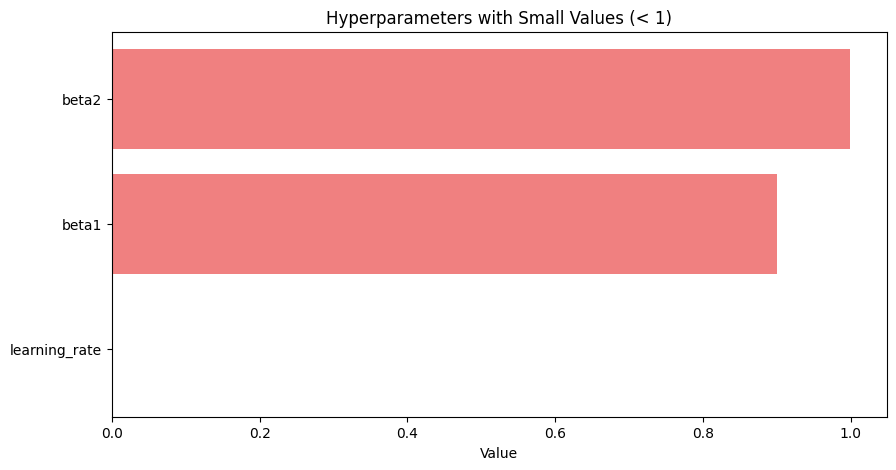

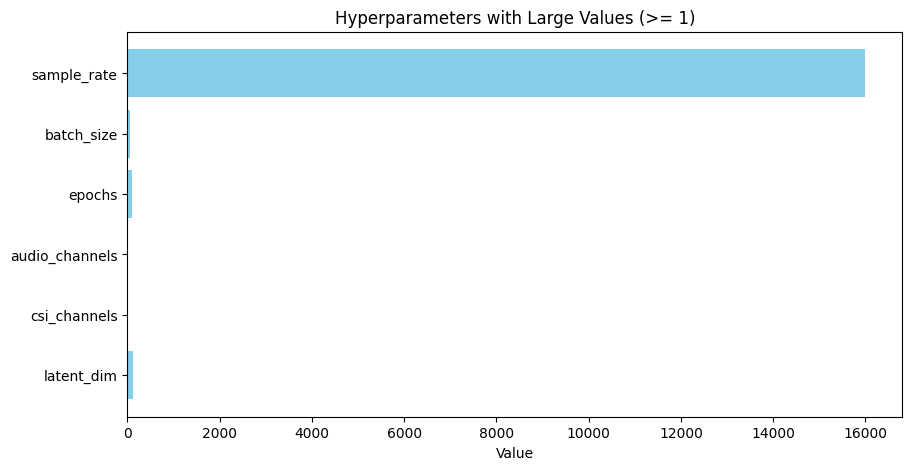

In [4]:

# Hyperparameters
latent_dim = 128            # Increase latent dimension for richer representations
csi_channels = 1            # Keep as is (depends on input data)
audio_channels = 1          # Keep as is (depends on input data)
epochs = 100                # Reduce epochs to avoid overfitting (can be adjusted if data is sufficient)
batch_size = 64             # Increase batch size for more stable gradients
learning_rate = 0.0002      # Slightly increase learning rate for faster convergence
beta1 = 0.9                 # Update for improved stability of Adam optimizer
beta2 = 0.999               # Keep as is (default value for Adam optimizer)
sample_rate = 16000         # Keep as is (dependent on your audio data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def visualize_hyperparameters(params):
    # Split the parameters into two categories: small values and large values
    small_values = {key: value for key, value in params.items() if value < 1}
    large_values = {key: value for key, value in params.items() if value >= 1}

    # Plot small values
    plt.figure(figsize=(10, 5))
    if small_values:
        names = list(small_values.keys())
        values = list(small_values.values())
        plt.barh(names, values, color="lightcoral")
        plt.xlabel("Value")
        plt.title("Hyperparameters with Small Values (< 1)")
        plt.show()

    # Plot large values
    plt.figure(figsize=(10, 5))
    if large_values:
        names = list(large_values.keys())
        values = list(large_values.values())
        plt.barh(names, values, color="skyblue")
        plt.xlabel("Value")
        plt.title("Hyperparameters with Large Values (>= 1)")
        plt.show()

# Complete hyperparameters dictionary
hyperparameters = {
    "latent_dim": latent_dim,
    "csi_channels": csi_channels,
    "audio_channels": audio_channels,
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "beta1": beta1,
    "beta2": beta2,
    "sample_rate": sample_rate
}

# Visualize hyperparameters
visualize_hyperparameters(hyperparameters)

# Dataset class
class CSIAudioDataset(Dataset):
    def __init__(self, data_df):
        self.data_df = data_df

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        logging.debug(f"Processing index: {idx}")
        csi_path = self.data_df.iloc[idx]['csi_path']
        csi_data = pd.read_csv(csi_path)
        subcarrier_cols = [col for col in csi_data.columns if col.startswith('subcarrier_')]
        csi_data = csi_data[subcarrier_cols].values.T  # shape: (8, N)
        # Interpolate to 400 data points for each subcarrier
        target_len = 400
        csi_data_resampled = np.array([
            np.interp(
                np.linspace(0, len(channel) - 1, target_len),
                np.arange(len(channel)),
                channel
            ) for channel in csi_data
        ])
        csi_tensor = torch.tensor(csi_data_resampled, dtype=torch.float32)

        # Load audio data from CSV and interpolate
        audio_path = self.data_df.iloc[idx]['audio_path']
        audio_data = pd.read_csv(audio_path, header=None).values.flatten()
        audio_data_resampled = np.interp(
            np.linspace(0, len(audio_data) - 1, target_len),
            np.arange(len(audio_data)),
            audio_data
        )
        audio_tensor = torch.tensor(audio_data_resampled, dtype=torch.float32)

        # Trim tensors to the same length
        min_len = min(csi_tensor.shape[1], len(audio_tensor))
        if min_len == 0:
            logging.warning(f"No valid audio length for index: {idx}")
            return None

        csi_tensor_trimmed = csi_tensor[:, :min_len]
        audio_trimmed = audio_tensor[:min_len]
        return csi_tensor_trimmed, audio_trimmed
        


### Data Loading

In [5]:
# Load dataset
train_df = pd.read_csv("data_paths.csv")  # change this to actually load data ()
train_dataset = CSIAudioDataset(train_df)

# Filter out None values
train_loader = DataLoader(
    [data for data in train_dataset if data is not None],
    batch_size=batch_size,
    shuffle=True
)



### Generator Model

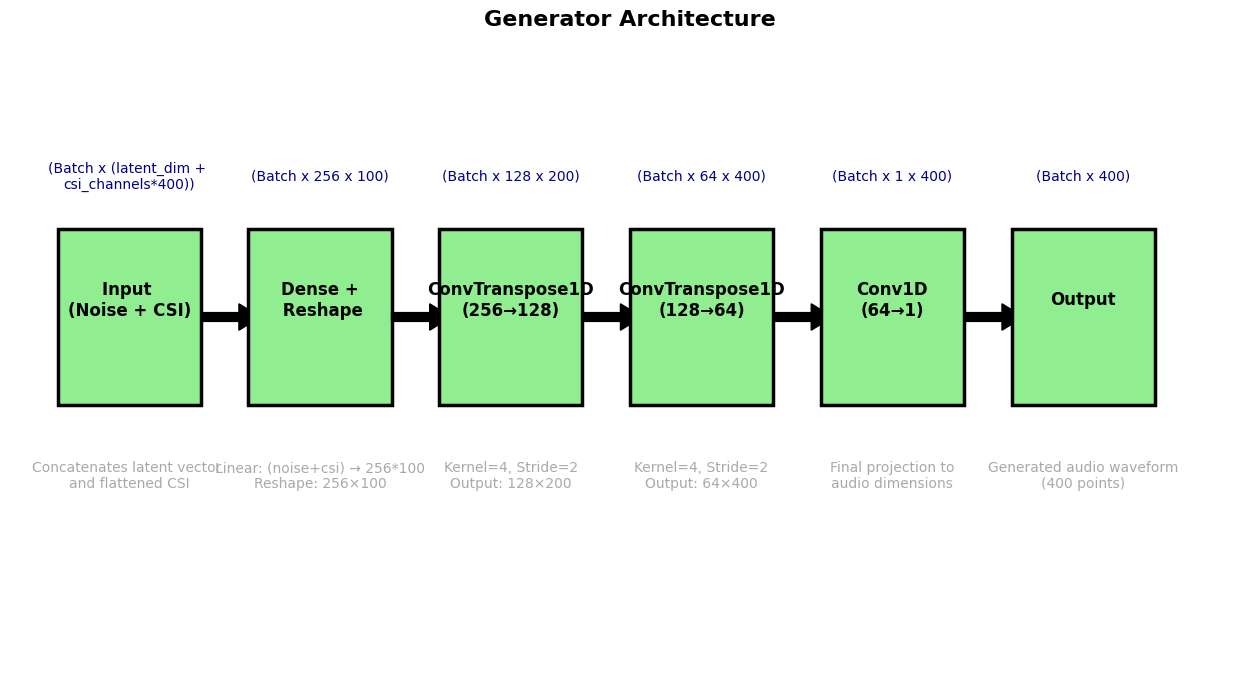

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim, csi_channels, audio_channels=1, csi_length=400):
        super(Generator, self).__init__()
        input_dim = latent_dim + csi_channels * csi_length  # Total input dimension after concatenation
        self.fc = nn.Linear(input_dim, 256 * 100)  # Project to 256 channels with 100 time steps

        self.conv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, audio_channels, kernel_size=1)  # Final projection to audio

    def forward(self, z, csi_data):
        # Flatten CSI data
        csi_flat = csi_data.view(csi_data.size(0), -1)
        
        # Concatenate latent vector and flattened CSI data
        x = torch.cat([z, csi_flat], dim=1)
        
        # Project to the correct shape for transposed convolutions
        x = self.fc(x).view(-1, 256, 100)  # Reshape to (batch_size, channels, time_steps)
        
        # Apply transposed convolutions
        x = F.relu(self.conv1(x))  # Output: (batch_size, 128, 200)
        x = F.relu(self.conv2(x))  # Output: (batch_size, 64, 400)
        x = self.conv3(x)          # Output: (batch_size, 1, 400)
        
        return torch.sigmoid(x.view(-1, 400))  # Reshape to (batch_size, 400)

def visualize_generator_architecture():
    fig, ax = plt.subplots(figsize=(16, 8))

    # Updated layers for corrected generator
    layers = [
        {"name": "Input \n(Noise + CSI)", "desc": "Concatenates latent vector \nand flattened CSI", "pos": (0, 0), "size": (3, 2)},
        {"name": "Dense +\n Reshape", "desc": "Linear: (noise+csi) → 256*100\nReshape: 256×100", "pos": (4, 0), "size": (3, 2)},
        {"name": "ConvTranspose1D\n(256→128)", "desc": "Kernel=4, Stride=2\nOutput: 128×200", "pos": (8, 0), "size": (3, 2)},
        {"name": "ConvTranspose1D\n(128→64)", "desc": "Kernel=4, Stride=2\nOutput: 64×400", "pos": (12, 0), "size": (3, 2)},
        {"name": "Conv1D\n(64→1)", "desc": "Final projection to\naudio dimensions", "pos": (16, 0), "size": (3, 2)},
        {"name": "Output", "desc": "Generated audio waveform\n(400 points)", "pos": (20, 0), "size": (3, 2)}
    ]
    
    # Updated data shapes
    data_shapes = [
        "(Batch x (latent_dim + \ncsi_channels*400))",
        "(Batch x 256 x 100)",
        "(Batch x 128 x 200)",
        "(Batch x 64 x 400)",
        "(Batch x 1 x 400)",
        "(Batch x 400)"
    ]
    
    # Draw layers and arrows
    for i, layer in enumerate(layers):
        # Draw the layer block
        rect = Rectangle(layer["pos"], *layer["size"], edgecolor="black", facecolor="lightgreen", linewidth=2.5)
        ax.add_patch(rect)
        
        # Layer name
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] / 2 + 0.2,
            layer["name"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=12,
            fontweight="bold"
        )
        
        # Layer description
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] - 0.8,
            layer["desc"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkgray"
        )
        
        # Data shape
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] + 0.6,
            data_shapes[i],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkblue"
        )
        
        # Draw arrow to the next layer
        if i < len(layers) - 1:
            start_x = layer["pos"][0] + layer["size"][0]
            start_y = layer["pos"][1] + layer["size"][1] / 2
            end_x = layers[i + 1]["pos"][0]
            end_y = layers[i + 1]["pos"][1] + layers[i + 1]["size"][1] / 2
            arrow = FancyArrow(start_x, start_y, end_x - start_x - 0.2, end_y - start_y, width=0.1, color="black")
            ax.add_patch(arrow)

    # Adjust axes
    ax.set_xlim(-1, 25)
    ax.set_ylim(-3, 4)
    ax.axis("off")
    ax.set_title("Generator Architecture", fontsize=16, fontweight="bold", pad=20)
    plt.show()

visualize_generator_architecture()



### Discriminator Model

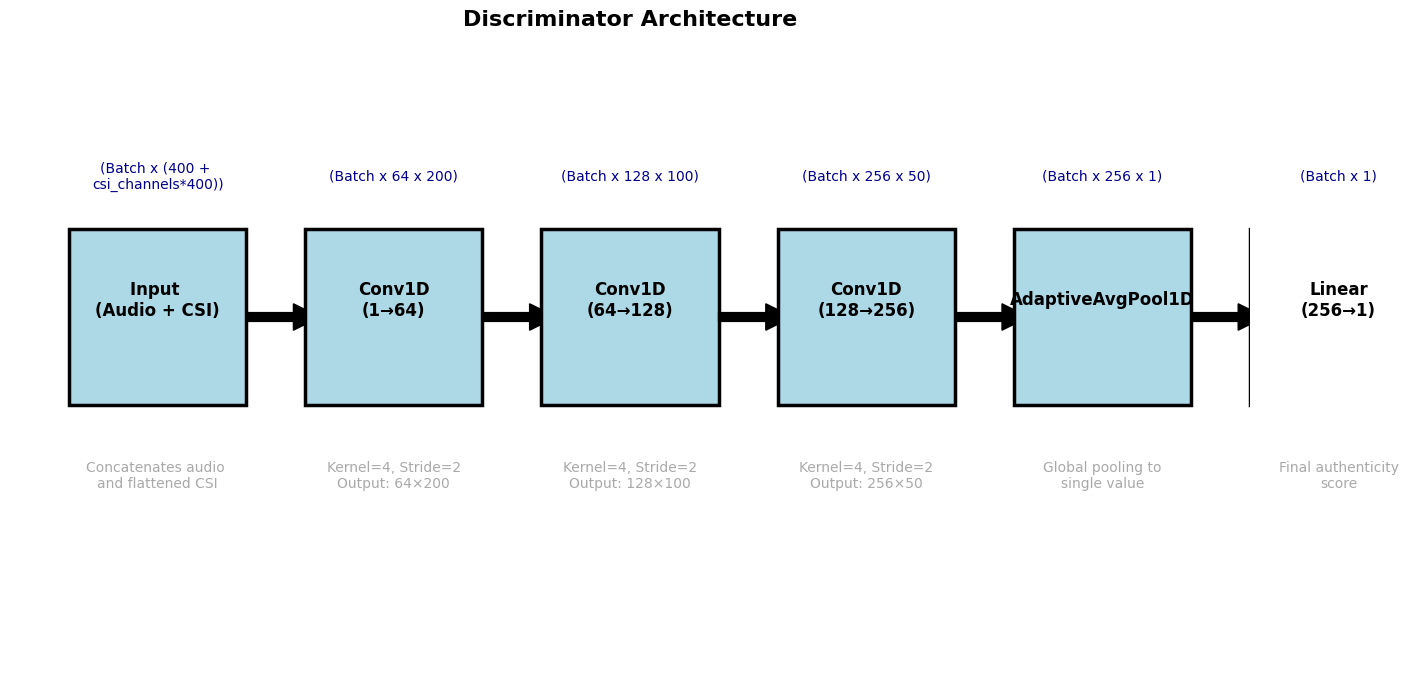

In [7]:
class Discriminator(nn.Module):
    def __init__(self, csi_channels):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, 1)
    
    def forward(self, audio, csi):
        csi_flat = csi.view(csi.size(0), -1)
        x = torch.cat([audio, csi_flat], dim=1).unsqueeze(1)  # [batch, 1, L]
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)  # [batch, 256]
        return torch.sigmoid(self.fc(x))  # [batch, 1]


def visualize_discriminator_architecture():
    fig, ax = plt.subplots(figsize=(16, 8))

    # Updated layers for corrected discriminator
    layers = [
        {"name": "Input \n(Audio + CSI)", "desc": "Concatenates audio \nand flattened CSI", "pos": (0, 0), "size": (3, 2)},
        {"name": "Conv1D\n(1→64)", "desc": "Kernel=4, Stride=2\nOutput: 64×200", "pos": (4, 0), "size": (3, 2)},
        {"name": "Conv1D\n(64→128)", "desc": "Kernel=4, Stride=2\nOutput: 128×100", "pos": (8, 0), "size": (3, 2)},
        {"name": "Conv1D\n(128→256)", "desc": "Kernel=4, Stride=2\nOutput: 256×50", "pos": (12, 0), "size": (3, 2)},
        {"name": "AdaptiveAvgPool1D", "desc": "Global pooling to\nsingle value", "pos": (16, 0), "size": (3, 2)},
        {"name": "Linear\n(256→1)", "desc": "Final authenticity\nscore", "pos": (20, 0), "size": (3, 2)}
    ]
    
    # Updated data shapes
    data_shapes = [
        "(Batch x (400 + \ncsi_channels*400))",
        "(Batch x 64 x 200)",
        "(Batch x 128 x 100)",
        "(Batch x 256 x 50)",
        "(Batch x 256 x 1)",
        "(Batch x 1)"
    ]

    
    # Draw layers and arrows
    for i, layer in enumerate(layers):
        # Draw the layer block
        rect = Rectangle(layer["pos"], *layer["size"], edgecolor="black", facecolor="lightblue", linewidth=2.5)
        ax.add_patch(rect)
        
        # Layer name
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] / 2 + 0.2,
            layer["name"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=12,
            fontweight="bold"
        )
        
        # Layer description
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] - 0.8,
            layer["desc"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkgray"
        )
        
        # Data shape
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] + 0.6,
            data_shapes[i],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkblue"
        )
        
        # Draw arrow to the next layer
        if i < len(layers) - 1:
            start_x = layer["pos"][0] + layer["size"][0]
            start_y = layer["pos"][1] + layer["size"][1] / 2
            end_x = layers[i + 1]["pos"][0]
            end_y = layers[i + 1]["pos"][1] + layers[i + 1]["size"][1] / 2
            arrow = FancyArrow(start_x, start_y, end_x - start_x - 0.2, end_y - start_y, width=0.1, color="black")
            ax.add_patch(arrow)

    # Adjust axes
    ax.set_xlim(-1, 20)
    ax.set_ylim(-3, 4)
    ax.axis("off")
    ax.set_title("Discriminator Architecture", fontsize=16, fontweight="bold", pad=20)
    plt.show()

visualize_discriminator_architecture()



### Loss Functions

In [8]:
def generator_loss(d_output):
    return F.binary_cross_entropy(d_output, torch.ones_like(d_output))

def discriminator_loss(d_output_real, d_output_fake):
    real_loss = F.binary_cross_entropy(d_output_real, torch.ones_like(d_output_real))
    fake_loss = F.binary_cross_entropy(d_output_fake, torch.zeros_like(d_output_fake))
    return real_loss + fake_loss


### Initialize Models and Optimizers

In [9]:
generator = Generator(latent_dim, csi_channels).to(device)
discriminator = Discriminator(csi_channels).to(device)

optimizer_g = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, beta2))
optimizer_d = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, beta2))


### Training Loop

In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import logging
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

class WindowedTrainer:
    def __init__(self, generator, discriminator, dataset, hyperparameters):
        """
        Initialize the windowed trainer.
        
        Args:
            generator: Generator model
            discriminator: Discriminator model
            dataset: CSIAudioDataset instance
            hyperparameters: Dictionary containing training hyperparameters
        """
        self.generator = generator.to(hyperparameters['device'])
        self.discriminator = discriminator.to(hyperparameters['device'])
        self.dataset = dataset
        self.hyperparameters = hyperparameters
        
        # Initialize optimizers
        self.optimizer_g = torch.optim.Adam(
            self.generator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        self.optimizer_d = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        
        # Initialize data loader with collate function to handle None values
        self.train_loader = DataLoader(
            dataset,
            batch_size=hyperparameters['batch_size'],
            shuffle=True,
            drop_last=True,
            collate_fn=self.collate_fn
        )
        
        # Initialize lists for tracking losses
        self.d_losses = []
        self.g_losses = []
        
    @staticmethod
    def collate_fn(batch):
        """
        Custom collate function to handle None values and create proper batches.
        """
        # Filter out None values
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None
        
        # Separate CSI and audio data
        csi_data = [item[0] for item in batch]
        audio_data = [item[1] for item in batch]
        
        # Stack the tensors
        csi_batch = torch.stack(csi_data)
        audio_batch = torch.stack(audio_data)
        
        return csi_batch, audio_batch
    
    def create_windows(self, data, window_size, stride):
        """
        Create windows from a batch of data.
        
        Args:
            data: Tensor of shape (batch_size, channels/features, sequence_length)
            window_size: Number of time steps in each window
            stride: Number of time steps to move between windows
            
        Returns:
            List of windows, each of shape (batch_size, channels/features, window_size)
        """
        windows = []
        # Handle the case where data is 2D (batch_size, sequence_length)
        if len(data.shape) == 2:
            data = data.unsqueeze(1)  # Add channel dimension
            
        for i in range(0, data.shape[2] - window_size + 1, stride):
            window = data[:, :, i:i + window_size]
            windows.append(window)
        return windows
    
    def train_epoch(self, epoch):
        """
        Train for one epoch using windowed data.
        """
        running_d_loss = 0.0
        running_g_loss = 0.0
        total_windows = 0
        
        # Window parameters
        window_size = 64  # Adjust based on your needs
        stride = 32      # 50% overlap
        
        for batch_idx, batch_data in enumerate(tqdm(self.train_loader, desc=f"Epoch {epoch + 1}")):
            # Skip empty batches
            if batch_data is None:
                continue
                
            csi_data, audio_data = batch_data
            
            # Move data to device
            csi_data = csi_data.to(self.hyperparameters['device'])  # Shape: (batch_size, 8, sequence_length)
            audio_data = audio_data.to(self.hyperparameters['device'])  # Shape: (batch_size, sequence_length)
            
            # Create windows
            csi_windows = self.create_windows(csi_data, window_size, stride)
            audio_windows = self.create_windows(audio_data, window_size, stride)
            
            # Update total windows count
            total_windows += len(csi_windows)
            
            # Train on each window
            for csi_window, audio_window in zip(csi_windows, audio_windows):
                # Ensure proper shapes
                if len(audio_window.shape) == 2:  # (batch_size, window_size)
                    audio_window = audio_window.unsqueeze(1)  # Add channel dimension
                
                # Train discriminator
                self.optimizer_d.zero_grad()
                
                # Generate fake audio
                z = torch.randn(
                    csi_window.size(0),
                    self.hyperparameters['latent_dim'],
                    device=self.hyperparameters['device']
                )
                fake_audio = self.generator(z, csi_window)
                
                # Real and fake discriminator outputs
                d_real = self.discriminator(audio_window, csi_window)
                d_fake = self.discriminator(fake_audio.detach(), csi_window)
                
                # Discriminator loss (WGAN-GP style)
                d_loss_real = -torch.mean(d_real)
                d_loss_fake = torch.mean(d_fake)
                d_loss = d_loss_real + d_loss_fake
                
                # Add gradient penalty
                gp = self.gradient_penalty(audio_window, fake_audio.detach(), csi_window)
                d_loss += 10.0 * gp
                
                d_loss.backward()
                self.optimizer_d.step()
                
                # Train generator
                self.optimizer_g.zero_grad()
                
                # Generate fake audio again
                fake_audio = self.generator(z, csi_window)
                d_fake = self.discriminator(fake_audio, csi_window)
                
                # Generator loss
                g_loss = -torch.mean(d_fake)
                
                g_loss.backward()
                self.optimizer_g.step()
                
                # Update running losses
                running_d_loss += d_loss.item()
                running_g_loss += g_loss.item()
        
        # Calculate average losses for this epoch
        avg_d_loss = running_d_loss / total_windows if total_windows > 0 else float('inf')
        avg_g_loss = running_g_loss / total_windows if total_windows > 0 else float('inf')
        
        self.d_losses.append(avg_d_loss)
        self.g_losses.append(avg_g_loss)
        
        return avg_d_loss, avg_g_loss
    
    def gradient_penalty(self, real_data, fake_data, condition):
        """
        Calculate gradient penalty for WGAN-GP.
        """
        batch_size = real_data.size(0)
        alpha = torch.rand(batch_size, 1, 1).to(self.hyperparameters['device'])
        alpha = alpha.expand_as(real_data)
        
        interpolated = alpha * real_data + (1 - alpha) * fake_data
        interpolated.requires_grad_(True)
        
        d_interpolated = self.discriminator(interpolated, condition)
        
        gradients = torch.autograd.grad(
            outputs=d_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(d_interpolated),
            create_graph=True,
            retain_graph=True
        )[0]
        
        gradients = gradients.view(batch_size, -1)
        gradient_norm = gradients.norm(2, dim=1)
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        
        return gradient_penalty
    
    def train(self):
        """
        Complete training loop for all epochs.
        """
        for epoch in range(self.hyperparameters['epochs']):
            d_loss, g_loss = self.train_epoch(epoch)
            
            # Log progress
            logging.info(
                f"Epoch [{epoch + 1}/{self.hyperparameters['epochs']}] "
                f"D_loss: {d_loss:.4f}, G_loss: {g_loss:.4f}"
            )
            
        
        # Plot training progress
        self.plot_training_progress()
    
    def plot_training_progress(self):
        """
        Plot the training losses.
        """
        plt.figure(figsize=(10, 5))
        plt.plot(self.d_losses, label='Discriminator Loss', color='red')
        plt.plot(self.g_losses, label='Generator Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.savefig('training_progress.png')
        plt.close()

def main():
    # Your hyperparameters are already defined
    hyperparameters = {
        "latent_dim": latent_dim,
        "csi_channels": csi_channels,
        "audio_channels": audio_channels,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "sample_rate": sample_rate,
        "device": device
    }
    
    # Create your dataset
    dataset = CSIAudioDataset(train_dataset)
    
    # Initialize your models
    generator = Generator(latent_dim, csi_channels).to(device)
    discriminator = Discriminator(csi_channels).to(device)
    
    # Initialize trainer
    trainer = WindowedTrainer(generator, discriminator, dataset, hyperparameters)
    
    # Start training
    trainer.train()

if __name__ == "__main__":
    main()

Epoch 1: 0it [00:00, ?it/s]
Epoch 2: 0it [00:00, ?it/s]
Epoch 3: 0it [00:00, ?it/s]
Epoch 4: 0it [00:00, ?it/s]
Epoch 5: 0it [00:00, ?it/s]
Epoch 6: 0it [00:00, ?it/s]
Epoch 7: 0it [00:00, ?it/s]
Epoch 8: 0it [00:00, ?it/s]
Epoch 9: 0it [00:00, ?it/s]
Epoch 10: 0it [00:00, ?it/s]
Epoch 11: 0it [00:00, ?it/s]
Epoch 12: 0it [00:00, ?it/s]
Epoch 13: 0it [00:00, ?it/s]
Epoch 14: 0it [00:00, ?it/s]
Epoch 15: 0it [00:00, ?it/s]
Epoch 16: 0it [00:00, ?it/s]
Epoch 17: 0it [00:00, ?it/s]
Epoch 18: 0it [00:00, ?it/s]
Epoch 19: 0it [00:00, ?it/s]
Epoch 20: 0it [00:00, ?it/s]
Epoch 21: 0it [00:00, ?it/s]
Epoch 22: 0it [00:00, ?it/s]
Epoch 23: 0it [00:00, ?it/s]
Epoch 24: 0it [00:00, ?it/s]
Epoch 25: 0it [00:00, ?it/s]
Epoch 26: 0it [00:00, ?it/s]
Epoch 27: 0it [00:00, ?it/s]
Epoch 28: 0it [00:00, ?it/s]
Epoch 29: 0it [00:00, ?it/s]
Epoch 30: 0it [00:00, ?it/s]
Epoch 31: 0it [00:00, ?it/s]
Epoch 32: 0it [00:00, ?it/s]
Epoch 33: 0it [00:00, ?it/s]
Epoch 34: 0it [00:00, ?it/s]
Epoch 35: 0it [00:00, ?

### Save Models

In [11]:
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")

### Full code in one

In [12]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Rectangle
import logging

# Hyperparameters
latent_dim = 128
csi_channels = 8  # Updated to match 8 subcarriers from dataset
audio_channels = 1
epochs = 100
batch_size = 64
learning_rate = 0.0002
beta1 = 0.9
beta2 = 0.999
sample_rate = 16000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset class (unchanged)
class CSIAudioDataset(Dataset):
    def __init__(self, data_df):
        self.data_df = data_df

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        logging.debug(f"Processing index: {idx}")
        csi_path = self.data_df.iloc[idx]['csi_path']
        csi_data = pd.read_csv(csi_path)
        subcarrier_cols = [col for col in csi_data.columns if col.startswith('subcarrier_')]
        csi_data = csi_data[subcarrier_cols].values.T  # Shape: (8, N)
        target_len = 400
        csi_data_resampled = np.array([
            np.interp(
                np.linspace(0, len(channel) - 1, target_len),
                np.arange(len(channel)),
                channel
            ) for channel in csi_data
        ])
        csi_tensor = torch.tensor(csi_data_resampled, dtype=torch.float32)

        audio_path = self.data_df.iloc[idx]['audio_path']
        audio_data = pd.read_csv(audio_path, header=None).values.flatten()
        audio_data_resampled = np.interp(
            np.linspace(0, len(audio_data) - 1, target_len),
            np.arange(len(audio_data)),
            audio_data
        )
        audio_tensor = torch.tensor(audio_data_resampled, dtype=torch.float32)

        min_len = min(csi_tensor.shape[1], len(audio_tensor))
        if min_len == 0:
            logging.warning(f"No valid audio length for index: {idx}")
            return None

        csi_tensor_trimmed = csi_tensor[:, :min_len]
        audio_trimmed = audio_tensor[:min_len]
        return csi_tensor_trimmed, audio_trimmed

# Fixed Generator class
class Generator(nn.Module):
    def __init__(self, latent_dim, csi_channels, audio_channels=1, csi_length=64):
        super(Generator, self).__init__()
        self.csi_length = csi_length  # Store csi_length as an attribute
        input_dim = latent_dim + csi_channels * csi_length
        T = csi_length // 4  # Adjusted for two ConvTranspose1d with stride=2
        self.fc = nn.Linear(input_dim, 256 * T)

        self.conv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, audio_channels, kernel_size=1)

    def forward(self, z, csi_data):
        csi_flat = csi_data.view(csi_data.size(0), -1)
        x = torch.cat([z, csi_flat], dim=1)
        T = self.csi_length // 4
        x = self.fc(x).view(-1, 256, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return torch.sigmoid(x.view(-1, self.csi_length))  # Dynamic reshaping

# Discriminator class (unchanged)
class Discriminator(nn.Module):
    def __init__(self, csi_channels):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, 1)
    
    def forward(self, audio, csi):
        csi_flat = csi.view(csi.size(0), -1)
        x = torch.cat([audio, csi_flat], dim=1).unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)
        return torch.sigmoid(self.fc(x))

# WindowedTrainer class (unchanged)
class WindowedTrainer:
    def __init__(self, generator, discriminator, dataset, hyperparameters):
        self.generator = generator.to(hyperparameters['device'])
        self.discriminator = discriminator.to(hyperparameters['device'])
        self.dataset = dataset
        self.hyperparameters = hyperparameters
        
        self.optimizer_g = torch.optim.Adam(
            self.generator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        self.optimizer_d = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        
        self.train_loader = DataLoader(
            dataset,
            batch_size=hyperparameters['batch_size'],
            shuffle=True,
            drop_last=True,
            collate_fn=self.collate_fn
        )
        
        self.d_losses = []
        self.g_losses = []
        
    @staticmethod
    def collate_fn(batch):
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None
        csi_data = [item[0] for item in batch]
        audio_data = [item[1] for item in batch]
        csi_batch = torch.stack(csi_data)
        audio_batch = torch.stack(audio_data)
        return csi_batch, audio_batch
    
    def create_windows(self, data, window_size, stride):
        windows = []
        if len(data.shape) == 2:
            data = data.unsqueeze(1)
        for i in range(0, data.shape[2] - window_size + 1, stride):
            window = data[:, :, i:i + window_size]
            windows.append(window)
        return windows
    
    def train_epoch(self, epoch):
        running_d_loss = 0.0
        running_g_loss = 0.0
        total_windows = 0
        window_size = 64
        stride = 32
        
        for batch_idx, batch_data in enumerate(tqdm(self.train_loader, desc=f"Epoch {epoch + 1}")):
            if batch_data is None:
                continue
            csi_data, audio_data = batch_data
            csi_data = csi_data.to(self.hyperparameters['device'])
            audio_data = audio_data.to(self.hyperparameters['device'])
            csi_windows = self.create_windows(csi_data, window_size, stride)
            audio_windows = self.create_windows(audio_data, window_size, stride)
            total_windows += len(csi_windows)
            for csi_window, audio_window in zip(csi_windows, audio_windows):
                if len(audio_window.shape) == 2:
                    audio_window = audio_window.unsqueeze(1)
                self.optimizer_d.zero_grad()
                z = torch.randn(
                    csi_window.size(0),
                    self.hyperparameters['latent_dim'],
                    device=self.hyperparameters['device']
                )
                fake_audio = self.generator(z, csi_window)
                d_real = self.discriminator(audio_window.squeeze(1), csi_window)
                d_fake = self.discriminator(fake_audio.detach(), csi_window)
                d_loss_real = -torch.mean(d_real)
                d_loss_fake = torch.mean(d_fake)
                d_loss = d_loss_real + d_loss_fake
                gp = self.gradient_penalty(audio_window.squeeze(1), fake_audio.detach(), csi_window)
                d_loss += 10.0 * gp
                d_loss.backward()
                self.optimizer_d.step()
                self.optimizer_g.zero_grad()
                fake_audio = self.generator(z, csi_window)
                d_fake = self.discriminator(fake_audio, csi_window)
                g_loss = -torch.mean(d_fake)
                g_loss.backward()
                self.optimizer_g.step()
                running_d_loss += d_loss.item()
                running_g_loss += g_loss.item()
        avg_d_loss = running_d_loss / total_windows if total_windows > 0 else float('inf')
        avg_g_loss = running_g_loss / total_windows if total_windows > 0 else float('inf')
        self.d_losses.append(avg_d_loss)
        self.g_losses.append(avg_g_loss)
        return avg_d_loss, avg_g_loss
    
    def gradient_penalty(self, real_data, fake_data, condition):
        batch_size = real_data.size(0)
        alpha = torch.rand(batch_size, 1).to(self.hyperparameters['device'])
        alpha = alpha.expand_as(real_data)
        interpolated = alpha * real_data + (1 - alpha) * fake_data
        interpolated.requires_grad_(True)
        d_interpolated = self.discriminator(interpolated, condition)
        gradients = torch.autograd.grad(
            outputs=d_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(d_interpolated),
            create_graph=True,
            retain_graph=True
        )[0]
        gradients = gradients.view(batch_size, -1)
        gradient_norm = gradients.norm(2, dim=1)
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        return gradient_penalty
    
    def train(self):
        for epoch in range(self.hyperparameters['epochs']):
            d_loss, g_loss = self.train_epoch(epoch)
            logging.info(
                f"Epoch [{epoch + 1}/{self.hyperparameters['epochs']}] "
                f"D_loss: {d_loss:.4f}, G_loss: {g_loss:.4f}"
            )
        self.plot_training_progress()
    
    def plot_training_progress(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.d_losses, label='Discriminator Loss', color='red')
        plt.plot(self.g_losses, label='Generator Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.savefig('training_progress.png')
        plt.close()

# Updated main function
def main():
    hyperparameters = {
        "latent_dim": latent_dim,
        "csi_channels": csi_channels,
        "audio_channels": audio_channels,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "sample_rate": sample_rate,
        "device": device
    }
    train_df = pd.read_csv("data_paths.csv")  # Ensure this file exists
    dataset = CSIAudioDataset(train_df)
    generator = Generator(latent_dim, csi_channels, csi_length=64).to(device)  # Set csi_length=64
    discriminator = Discriminator(csi_channels).to(device)
    trainer = WindowedTrainer(generator, discriminator, dataset, hyperparameters)
    trainer.train()

if __name__ == "__main__":
    main()

Epoch 1: 0it [00:00, ?it/s]
Epoch 2: 0it [00:00, ?it/s]
Epoch 3: 0it [00:00, ?it/s]
Epoch 4: 0it [00:00, ?it/s]
Epoch 5: 0it [00:00, ?it/s]
Epoch 6: 0it [00:00, ?it/s]
Epoch 7: 0it [00:00, ?it/s]
Epoch 8: 0it [00:00, ?it/s]
Epoch 9: 0it [00:00, ?it/s]
Epoch 10: 0it [00:00, ?it/s]
Epoch 11: 0it [00:00, ?it/s]
Epoch 12: 0it [00:00, ?it/s]
Epoch 13: 0it [00:00, ?it/s]
Epoch 14: 0it [00:00, ?it/s]
Epoch 15: 0it [00:00, ?it/s]
Epoch 16: 0it [00:00, ?it/s]
Epoch 17: 0it [00:00, ?it/s]
Epoch 18: 0it [00:00, ?it/s]
Epoch 19: 0it [00:00, ?it/s]
Epoch 20: 0it [00:00, ?it/s]
Epoch 21: 0it [00:00, ?it/s]
Epoch 22: 0it [00:00, ?it/s]
Epoch 23: 0it [00:00, ?it/s]
Epoch 24: 0it [00:00, ?it/s]
Epoch 25: 0it [00:00, ?it/s]
Epoch 26: 0it [00:00, ?it/s]
Epoch 27: 0it [00:00, ?it/s]
Epoch 28: 0it [00:00, ?it/s]
Epoch 29: 0it [00:00, ?it/s]
Epoch 30: 0it [00:00, ?it/s]
Epoch 31: 0it [00:00, ?it/s]
Epoch 32: 0it [00:00, ?it/s]
Epoch 33: 0it [00:00, ?it/s]
Epoch 34: 0it [00:00, ?it/s]
Epoch 35: 0it [00:00, ?

### Generating

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import os
import soundfile as sf

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Correct Generator definition (MUST MATCH TRAINED ARCHITECTURE)
class Generator(nn.Module):
    def __init__(self, latent_dim=128, csi_channels=8, audio_channels=1, csi_length=400):
        super(Generator, self).__init__()
        input_dim = latent_dim + csi_channels * csi_length
        self.fc = nn.Linear(input_dim, 256 * 100)
        self.conv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, audio_channels, kernel_size=1)

    def forward(self, z, csi_data):
        csi_flat = csi_data.view(csi_data.size(0), -1)
        x = torch.cat([z, csi_flat], dim=1)
        x = self.fc(x).view(-1, 256, 100)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return torch.sigmoid(x.view(-1, 400))

# Model parameters (MUST MATCH TRAINING PARAMETERS)
latent_dim = 128
csi_channels = 8
csi_length = 400

# Initialize and load generator
generator = Generator(latent_dim=latent_dim, csi_channels=csi_channels)
generator.load_state_dict(
    torch.load('generator.pth', 
              map_location=device, 
              weights_only=True)
)
generator.to(device)

# Process CSI data (top 8 subcarriers)
csi_data_path = 'data_capture/csi/8_csi_filtered/top8_filtered_csi_data_2024-08-17_23-16-37.224.csv'  # <-- update filename as needed
raw_csi_df = pd.read_csv(csi_data_path)
subcarrier_cols = [col for col in raw_csi_df.columns if col.startswith('subcarrier_')]
raw_csi = raw_csi_df[subcarrier_cols].values.T  # shape: (8, N)

# Interpolate each subcarrier to 400 points
target_len = 400
processed_csi = np.array([
    np.interp(
        np.linspace(0, len(channel) - 1, target_len),
        np.arange(len(channel)),
        channel
    ) for channel in raw_csi
])  # shape: (8, 400)

# Create CSI tensor
sample_csi = torch.tensor(processed_csi, dtype=torch.float32)
sample_csi = sample_csi.view(1, csi_channels, csi_length).to(device)

# Verify dimensions
if sample_csi.shape != (1, csi_channels, csi_length):
    raise ValueError(f"CSI tensor shape mismatch: {sample_csi.shape}")

# Function to generate synthetic audio
def generate_synthetic_audio(generator, latent_dim, csi_data_sample, num_samples, 
                            output_dir, target_length=1600, sample_rate=16000):
    generator.eval()
    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_samples):
        z = torch.randn(1, latent_dim).to(device)
        with torch.no_grad():
            generated_audio = generator(z, csi_data_sample)
        
        audio_400 = generated_audio.squeeze().cpu().numpy()
        x_original = np.linspace(0, 1, len(audio_400))
        x_target = np.linspace(0, 1, target_length)
        audio_interpolated = np.interp(x_target, x_original, audio_400)
        audio_interpolated = np.clip(audio_interpolated * 2 - 1, -1.0, 1.0)

        output_path = os.path.join(output_dir, f"generated_audio_{i+1}_{target_length}pts.wav")
        sf.write(output_path, audio_interpolated, sample_rate)
        print(f"Generated {target_length}-point audio at: {output_path}")

# Generate audio samples
generate_synthetic_audio(
    generator=generator,
    latent_dim=latent_dim,
    csi_data_sample=sample_csi,
    num_samples=2,
    output_dir="generated_audio",
    target_length=32000
)

RuntimeError: Error(s) in loading state_dict for Generator:
	size mismatch for fc.weight: copying a param with shape torch.Size([25600, 528]) from checkpoint, the shape in current model is torch.Size([25600, 3328]).

## Complete Code - 30 july


2025-08-04 16:27:33,868 - INFO - Starting IMPROVED CSI-Audio GAN training...
2025-08-04 16:27:33,869 - INFO - Using device: cpu
2025-08-04 16:27:33,871 - INFO - KEY IMPROVEMENTS:
2025-08-04 16:27:33,872 - INFO - - Separate learning rates: G=0.0002, D=0.0001
2025-08-04 16:27:33,873 - INFO - - Discriminator training frequency: every 2 generator updates
2025-08-04 16:27:33,874 - INFO - - Reconstruction loss weight: 10.0
2025-08-04 16:27:33,875 - INFO - - Feature matching loss weight: 2.0
2025-08-04 16:27:33,877 - INFO - - Gradient penalty weight: 10.0
2025-08-04 16:27:33,885 - INFO - Dataset created with 48 matched pairs
2025-08-04 16:27:33,971 - INFO - Improved Generator parameters: 8,574,017
2025-08-04 16:27:33,973 - INFO - Improved Discriminator parameters: 691,649


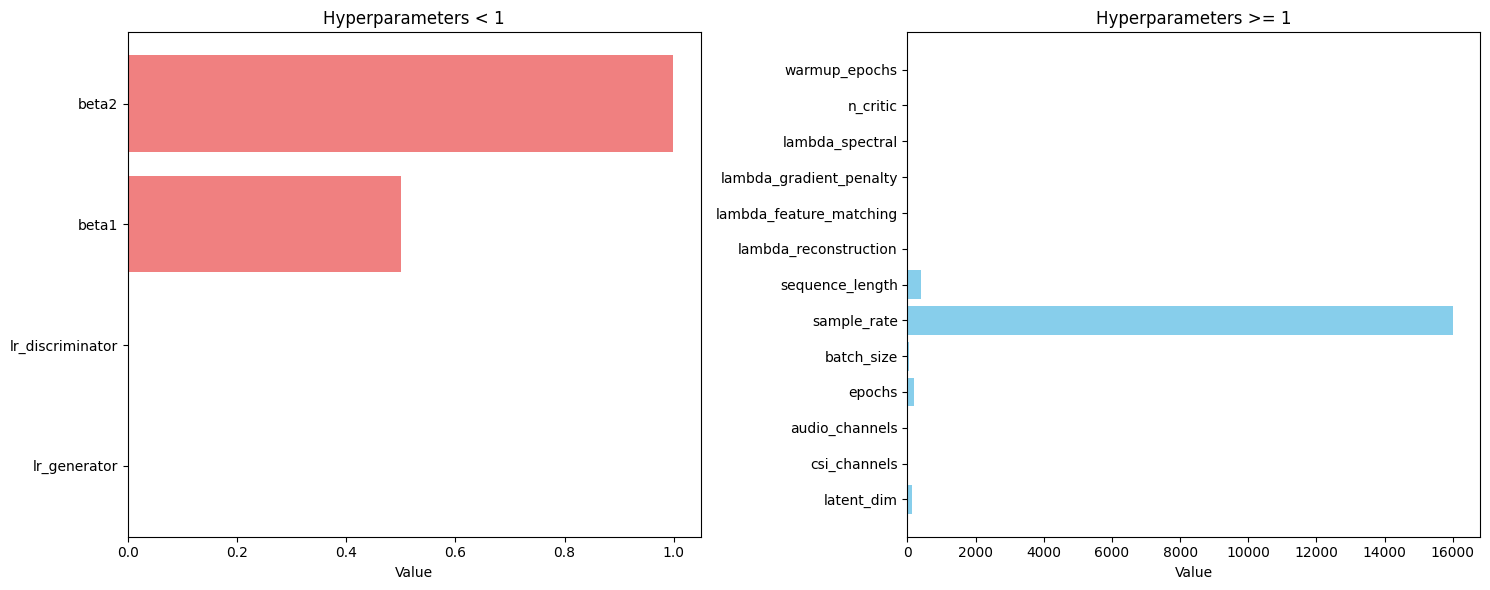

Epoch 1/200: 100%|██████████| 1/1 [00:03<00:00,  3.41s/it, D_loss=11.2234, G_loss=19.2767, Recon=7.7847, FM=0.2669]
2025-08-04 16:27:38,257 - INFO - Epoch 1: D_loss=11.2234, G_loss=19.2767, Recon=7.7847, FM=0.2669
Epoch 2/200: 100%|██████████| 1/1 [00:03<00:00,  3.62s/it, D_loss=11.2252, G_loss=18.4355, Recon=7.4567, FM=0.2509]
2025-08-04 16:27:41,887 - INFO - Epoch 2: D_loss=11.2252, G_loss=18.4355, Recon=7.4567, FM=0.2509
Epoch 3/200: 100%|██████████| 1/1 [00:03<00:00,  3.46s/it, D_loss=11.2266, G_loss=18.5950, Recon=7.4166, FM=0.2537]
2025-08-04 16:27:45,347 - INFO - Epoch 3: D_loss=11.2266, G_loss=18.5950, Recon=7.4166, FM=0.2537
Epoch 4/200: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it, D_loss=11.2260, G_loss=18.6466, Recon=7.5587, FM=0.2533]
2025-08-04 16:27:48,707 - INFO - Epoch 4: D_loss=11.2260, G_loss=18.6466, Recon=7.5587, FM=0.2533
Epoch 5/200: 100%|██████████| 1/1 [00:03<00:00,  3.30s/it, D_loss=11.2182, G_loss=17.7923, Recon=7.2359, FM=0.2347]
2025-08-04 16:27:52,012 - IN

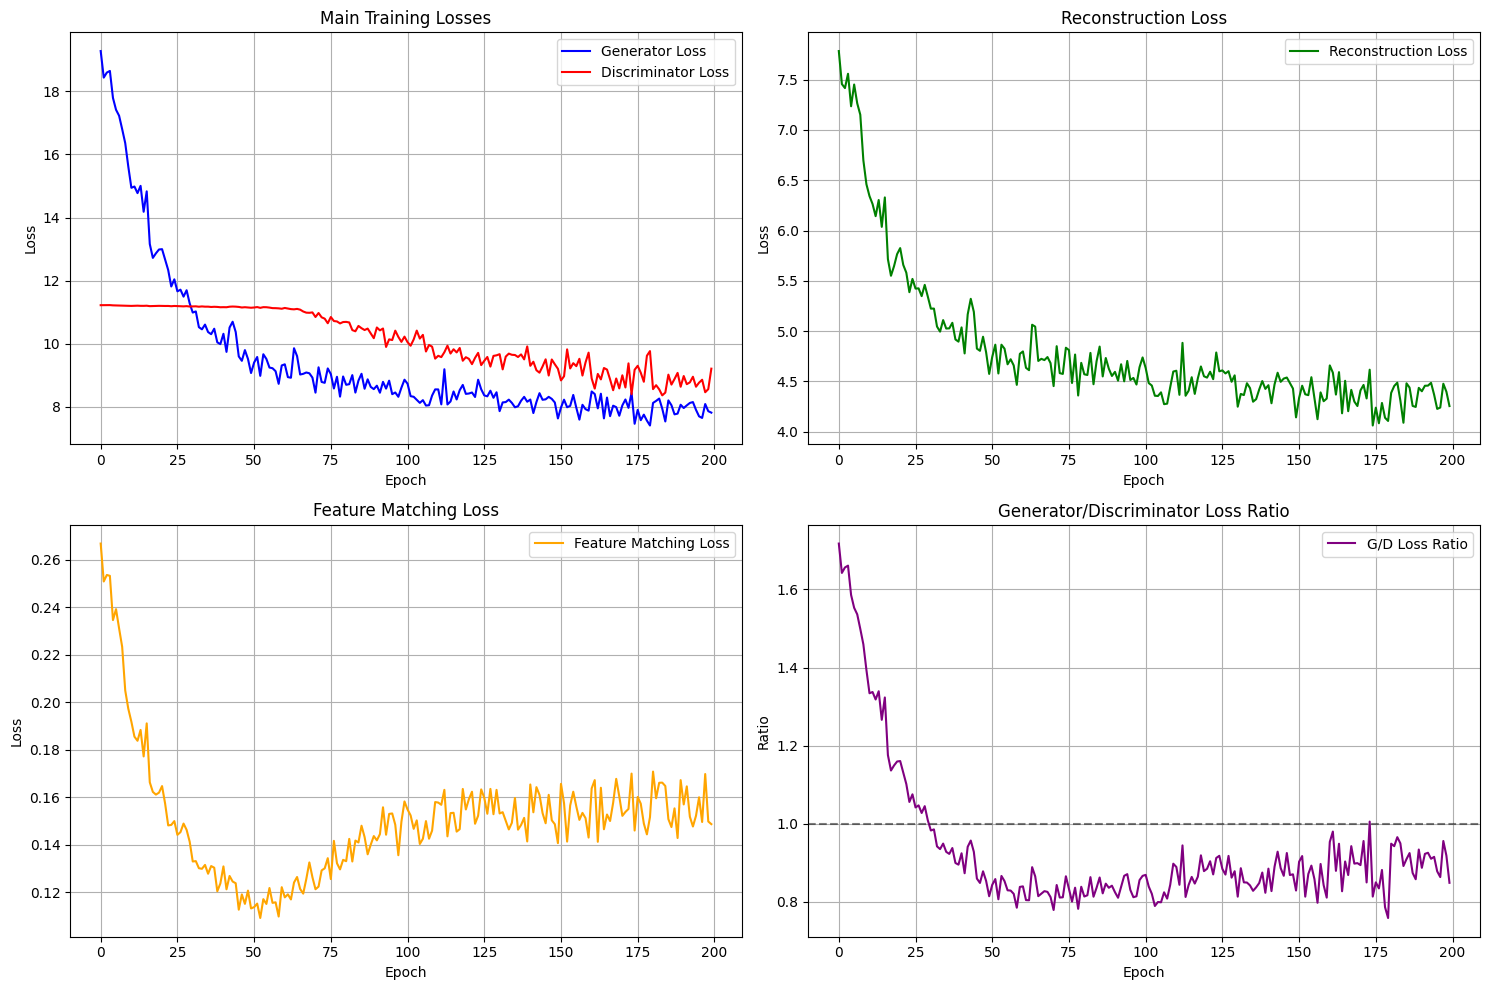

2025-08-04 16:39:01,082 - INFO - Improved models saved successfully!
2025-08-04 16:39:01,089 - INFO - TRAINING COMPLETED SUCCESSFULLY!
2025-08-04 16:39:01,090 - INFO - Final Generator Loss: 7.8185
2025-08-04 16:39:01,091 - INFO - Final Discriminator Loss: 9.2121
2025-08-04 16:39:01,092 - INFO - Final G/D Ratio: 0.8487 (target: ~1.0)


In [20]:

import os
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow
import logging
from tqdm import tqdm
import soundfile as sf

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# ============================================================================
# IMPROVED CONFIGURATION AND HYPERPARAMETERS
# ============================================================================

# Directories - using flexible paths
CSI_DIRECTORY = "data/csi"
AUDIO_DIRECTORY = "data/audio"

# IMPROVED Hyperparameters based on analysis
HYPERPARAMETERS = {
    "latent_dim": 128,
    "csi_channels": 8,
    "audio_channels": 1,
    "epochs": 200,  # Increased for better convergence
    "batch_size": 32,

    # CRITICAL: Separate learning rates for better balance
    "lr_generator": 0.0002,        # Keep current
    "lr_discriminator": 0.0001,    # Reduced by half for better balance

    "beta1": 0.5,
    "beta2": 0.999,
    "sample_rate": 16000,
    "sequence_length": 400,

    # NEW: Loss weights for better training
    "lambda_reconstruction": 10.0,    # Reconstruction loss weight
    "lambda_feature_matching": 2.0,   # Feature matching loss weight
    "lambda_gradient_penalty": 10.0,  # Gradient penalty weight
    "lambda_spectral": 1.0,          # Spectral loss weight

    # NEW: Training schedule parameters
    "n_critic": 2,                   # Train discriminator every 2 generator updates
    "warmup_epochs": 10,             # Learning rate warmup

    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# ============================================================================
# IMPROVED DATA HANDLING FUNCTIONS
# ============================================================================

def extract_timestamp(filename):
    """Extract timestamp from filename with error handling"""
    try:
        match = re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}\.\d+)', filename)
        return match.group(1) if match else None
    except Exception as e:
        logging.error(f"Error extracting timestamp from {filename}: {e}")
        return None

def create_sample_data():
    """Create more realistic sample data for testing"""
    logging.info("Creating improved sample data...")

    os.makedirs(CSI_DIRECTORY, exist_ok=True)
    os.makedirs(AUDIO_DIRECTORY, exist_ok=True)

    timestamps = [
        "2025-05-07_20-11-50.303",
        "2025-05-07_20-12-50.303", 
        "2025-05-07_20-13-50.303",
        "2025-05-07_20-14-50.303",
        "2025-05-07_20-15-50.303",
        "2025-05-07_20-16-50.303",
        "2025-05-07_20-17-50.303",
        "2025-05-07_20-18-50.303"  # More samples for better training
    ]

    np.random.seed(42)

    for i, ts in enumerate(timestamps):
        # Create more realistic CSI data
        csi_filename = f"top8_filtered_csi_data_{ts}.csv"
        csi_path = os.path.join(CSI_DIRECTORY, csi_filename)

        n_samples = 500 + np.random.randint(-50, 51)  # Variable length
        csi_data = {}

        for j in range(8):
            # More complex CSI patterns
            t = np.linspace(0, 4*np.pi, n_samples)
            base_freq = 0.5 + j * 0.1  # Different frequencies per subcarrier

            signal = (10 * np.sin(base_freq * t) + 
                     5 * np.cos(2 * base_freq * t) +
                     2 * np.sin(4 * base_freq * t))

            # Add correlated patterns between subcarriers
            if j > 0:
                signal += 0.3 * csi_data[f'subcarrier_{j-1}']

            # Add realistic noise and fading
            noise = np.random.randn(n_samples) * 1.5
            fading = np.exp(-0.001 * np.arange(n_samples)) * (1 + 0.1 * np.sin(0.01 * np.arange(n_samples)))

            csi_data[f'subcarrier_{j}'] = (signal + noise) * fading

        # Add timestamp column
        csi_data['timestamp'] = np.arange(n_samples)
        pd.DataFrame(csi_data).to_csv(csi_path, index=False)

        # Create correlated audio data
        audio_filename = f"{ts}.csv"
        audio_path = os.path.join(AUDIO_DIRECTORY, audio_filename)

        # Audio should have some correlation with CSI
        base_audio = np.mean([csi_data[f'subcarrier_{j}'] for j in range(8)], axis=0)
        base_audio = base_audio / (np.std(base_audio) + 1e-8)  # Normalize

        # Add audio-specific patterns
        t_audio = np.linspace(0, 2*np.pi, n_samples)
        audio_patterns = (0.5 * np.sin(t_audio) + 
                         0.3 * np.sin(3 * t_audio) + 
                         0.2 * np.sin(5 * t_audio))

        # Combine CSI influence with audio patterns
        audio_data = 0.6 * base_audio + 0.4 * audio_patterns
        audio_data += np.random.randn(n_samples) * 0.05  # Light noise

        # Normalize to reasonable range
        audio_data = np.tanh(audio_data * 0.8)

        pd.DataFrame(audio_data).to_csv(audio_path, index=False, header=False)

    logging.info(f"Created {len(timestamps)} improved sample data pairs")

def load_and_prepare_data():
    """Load and prepare data with comprehensive error handling"""
    try:
        if not os.path.exists(CSI_DIRECTORY) or not os.path.exists(AUDIO_DIRECTORY):
            create_sample_data()

        csi_files = []
        audio_files = []

        if os.path.exists(CSI_DIRECTORY):
            csi_files = [f for f in os.listdir(CSI_DIRECTORY) 
                        if f.startswith('top8_filtered_csi_data_') and f.endswith('.csv')]

        if os.path.exists(AUDIO_DIRECTORY):
            audio_files = [f for f in os.listdir(AUDIO_DIRECTORY) if f.endswith('.csv')]

        csi_timestamps = {extract_timestamp(f): f for f in csi_files if extract_timestamp(f)}
        audio_timestamps = {extract_timestamp(f): f for f in audio_files if extract_timestamp(f)}

        common_timestamps = sorted(set(csi_timestamps.keys()) & set(audio_timestamps.keys()))

        if len(common_timestamps) == 0:
            logging.warning("No matching pairs found. Creating sample data...")
            create_sample_data()
            return load_and_prepare_data()

        data_pairs = []
        for ts in common_timestamps:
            data_pairs.append({
                "csi_path": os.path.join(CSI_DIRECTORY, csi_timestamps[ts]),
                "audio_path": os.path.join(AUDIO_DIRECTORY, audio_timestamps[ts])
            })

        df = pd.DataFrame(data_pairs)
        output_path = "data_paths.csv"
        df.to_csv(output_path, index=False)

        logging.info(f"Dataset created with {len(df)} matched pairs")
        return df

    except Exception as e:
        logging.error(f"Error in data preparation: {e}")
        raise

# ============================================================================
# IMPROVED DATASET CLASS
# ============================================================================

class ImprovedCSIAudioDataset(Dataset):
    def __init__(self, data_df, sequence_length=400):
        self.data_df = data_df
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data_df)

    def preprocess_csi_improved(self, csi_data):
        """Improved CSI preprocessing - per-channel normalization"""
        normalized = []
        for i, channel in enumerate(csi_data):
            # Per-channel normalization
            channel_norm = (channel - channel.mean()) / (channel.std() + 1e-8)
            # Clip extreme values for stability
            channel_norm = torch.clamp(channel_norm, -3, 3)
            normalized.append(channel_norm)
        return torch.stack(normalized)

    def preprocess_audio_improved(self, audio_data):
        """Improved audio preprocessing"""
        # Normalize
        audio_norm = (audio_data - audio_data.mean()) / (audio_data.std() + 1e-8)
        # Clip extreme values
        audio_norm = torch.clamp(audio_norm, -3, 3)
        return audio_norm

    def __getitem__(self, idx):
        try:
            # Load CSI data
            csi_path = self.data_df.iloc[idx]['csi_path']
            if not os.path.exists(csi_path):
                logging.warning(f"CSI file not found: {csi_path}")
                return None

            csi_data = pd.read_csv(csi_path)
            subcarrier_cols = [col for col in csi_data.columns if col.startswith('subcarrier_')]

            if len(subcarrier_cols) == 0:
                logging.warning(f"No subcarrier columns in {csi_path}")
                return None

            # Process CSI data
            csi_values = csi_data[subcarrier_cols].values.T

            # Resample to target length
            csi_resampled = np.array([
                np.interp(
                    np.linspace(0, len(channel) - 1, self.sequence_length),
                    np.arange(len(channel)),
                    channel
                ) for channel in csi_values
            ])

            # Load audio data
            audio_path = self.data_df.iloc[idx]['audio_path']
            if not os.path.exists(audio_path):
                logging.warning(f"Audio file not found: {audio_path}")
                return None

            audio_data = pd.read_csv(audio_path, header=None).values.flatten()

            # Resample audio to target length
            audio_resampled = np.interp(
                np.linspace(0, len(audio_data) - 1, self.sequence_length),
                np.arange(len(audio_data)),
                audio_data
            )

            # Convert to tensors
            csi_tensor = torch.tensor(csi_resampled, dtype=torch.float32)
            audio_tensor = torch.tensor(audio_resampled, dtype=torch.float32)

            # Apply improved preprocessing
            csi_tensor = self.preprocess_csi_improved(csi_tensor)
            audio_tensor = self.preprocess_audio_improved(audio_tensor)

            return csi_tensor, audio_tensor

        except Exception as e:
            logging.error(f"Error processing index {idx}: {e}")
            return None

# ============================================================================
# IMPROVED MODEL ARCHITECTURES
# ============================================================================

class ResidualBlock(nn.Module):
    """Residual block for improved generator"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)

class ImprovedGenerator(nn.Module):
    def __init__(self, latent_dim, csi_channels, sequence_length=400):
        super().__init__()
        self.latent_dim = latent_dim
        self.csi_channels = csi_channels
        self.sequence_length = sequence_length

        # Calculate input dimension
        self.csi_input_dim = csi_channels * sequence_length
        self.total_input_dim = latent_dim + self.csi_input_dim

        # Improved generator network
        self.fc1 = nn.Linear(self.total_input_dim, 512)
        self.fc2 = nn.Linear(512, 256 * 50)

        self.conv_layers = nn.Sequential(
            # Upsample from 50 to 100
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            # Add residual block
            ResidualBlock(128),

            # Upsample from 100 to 200
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),

            # Add residual block
            ResidualBlock(64),

            # Upsample from 200 to 400
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),

            # Add residual block
            ResidualBlock(32),

            # Final layer
            nn.Conv1d(32, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, csi_data):
        batch_size = noise.size(0)

        # Flatten CSI data
        csi_flat = csi_data.view(batch_size, -1)

        # Concatenate noise and CSI
        x = torch.cat([noise, csi_flat], dim=1)

        # Pass through fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Reshape for convolution
        x = x.view(batch_size, 256, 50)

        # Pass through convolutional layers
        x = self.conv_layers(x)

        return x.view(batch_size, self.sequence_length)

class ImprovedDiscriminator(nn.Module):
    def __init__(self, csi_channels, sequence_length=400):
        super().__init__()
        self.csi_channels = csi_channels
        self.sequence_length = sequence_length

        # Input: audio + flattened CSI
        self.input_dim = sequence_length + (csi_channels * sequence_length)

        # Improved discriminator with spectral normalization
        self.conv_layers = nn.ModuleList([
            spectral_norm(nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)),
            spectral_norm(nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)),
            spectral_norm(nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)),
            spectral_norm(nn.Conv1d(256, 512, kernel_size=4, stride=2, padding=1)),
        ])

        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(128),
            nn.BatchNorm1d(256),
            nn.BatchNorm1d(512),
        ])

        self.leaky_relu = nn.LeakyReLU(0.2, inplace=True)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = spectral_norm(nn.Linear(512, 1))

    def forward(self, audio, csi, return_features=False):
        batch_size = audio.size(0)
        features = []

        # Flatten CSI and concatenate with audio
        csi_flat = csi.view(batch_size, -1)
        x = torch.cat([audio, csi_flat], dim=1)

        # Add channel dimension
        x = x.unsqueeze(1)

        # Pass through conv layers
        for i, conv in enumerate(self.conv_layers):
            x = conv(x)
            if i > 0:  # Skip first layer for batch norm
                x = self.batch_norms[i-1](x)
            x = self.leaky_relu(x)

            if return_features:
                features.append(x.clone())

        # Global average pooling and classification
        x = self.adaptive_pool(x)
        x = x.view(batch_size, -1)
        output = self.fc(x)

        if return_features:
            return output, features
        return output

# ============================================================================
# IMPROVED LOSS FUNCTIONS
# ============================================================================

def feature_matching_loss(real_features, fake_features):
    """Feature matching loss for better generator training"""
    loss = 0
    for real_feat, fake_feat in zip(real_features, fake_features):
        loss += F.l1_loss(fake_feat.mean(0), real_feat.mean(0))
    return loss

def gradient_penalty(discriminator, real_data, fake_data, csi_data, device):
    """Gradient penalty for more stable training"""
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1).to(device)

    interpolated = alpha * real_data + (1 - alpha) * fake_data
    interpolated.requires_grad_(True)

    d_interpolated = discriminator(interpolated, csi_data)
    gradients = torch.autograd.grad(
        outputs=d_interpolated, inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True, retain_graph=True
    )[0]

    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

def spectral_loss(generated, target):
    """Spectral loss for better audio quality"""
    try:
        # Simple spectral comparison using FFT
        gen_fft = torch.fft.fft(generated, dim=-1)
        tar_fft = torch.fft.fft(target, dim=-1)

        magnitude_loss = F.l1_loss(torch.abs(gen_fft), torch.abs(tar_fft))
        return magnitude_loss
    except:
        # Fallback to simple L1 loss if FFT fails
        return F.l1_loss(generated, target)

# ============================================================================
# IMPROVED TRAINING FUNCTIONS
# ============================================================================

def train_improved_gan(generator, discriminator, dataloader, hyperparams):
    """Improved training function with better balance and loss functions"""

    # Initialize optimizers with different learning rates
    optimizer_g = optim.Adam(
        generator.parameters(),
        lr=hyperparams['lr_generator'],
        betas=(hyperparams['beta1'], hyperparams['beta2'])
    )

    optimizer_d = optim.Adam(
        discriminator.parameters(),
        lr=hyperparams['lr_discriminator'],  # Lower learning rate
        betas=(hyperparams['beta1'], hyperparams['beta2'])
    )

    # Learning rate schedulers
    scheduler_g = optim.lr_scheduler.ExponentialLR(optimizer_g, gamma=0.995)
    scheduler_d = optim.lr_scheduler.ExponentialLR(optimizer_d, gamma=0.995)

    # Loss function
    criterion = nn.BCEWithLogitsLoss()

    # Training history
    g_losses = []
    d_losses = []
    reconstruction_losses = []
    feature_matching_losses = []

    device = hyperparams['device']

    for epoch in range(hyperparams['epochs']):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        epoch_recon_loss = 0.0
        epoch_fm_loss = 0.0
        num_batches = 0

        # Learning rate warmup
        if epoch < hyperparams['warmup_epochs']:
            lr_factor = (epoch + 1) / hyperparams['warmup_epochs']
            for param_group in optimizer_g.param_groups:
                param_group['lr'] = hyperparams['lr_generator'] * lr_factor
            for param_group in optimizer_d.param_groups:
                param_group['lr'] = hyperparams['lr_discriminator'] * lr_factor

        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{hyperparams['epochs']}")

        for batch_idx, batch_data in enumerate(progress_bar):
            if batch_data is None:
                continue

            csi_data, audio_data = batch_data
            batch_size = csi_data.size(0)

            csi_data = csi_data.to(device)
            audio_data = audio_data.to(device)

            # Create labels with label smoothing
            real_labels = torch.ones(batch_size, 1, device=device) * 0.9  # Label smoothing
            fake_labels = torch.zeros(batch_size, 1, device=device) + 0.1  # Label smoothing

            # ============================================
            # Train Generator
            # ============================================
            optimizer_g.zero_grad()

            noise = torch.randn(batch_size, hyperparams['latent_dim'], device=device)
            fake_audio = generator(noise, csi_data)

            # Get discriminator output and features
            fake_output, fake_features = discriminator(fake_audio, csi_data, return_features=True)

            # Adversarial loss
            g_loss_adversarial = criterion(fake_output, real_labels)

            # Reconstruction loss
            g_loss_reconstruction = F.l1_loss(fake_audio, audio_data) * hyperparams['lambda_reconstruction']

            # Feature matching loss
            real_output, real_features = discriminator(audio_data, csi_data, return_features=True)
            g_loss_fm = feature_matching_loss(real_features, fake_features) * hyperparams['lambda_feature_matching']

            # Spectral loss
            g_loss_spectral = spectral_loss(fake_audio, audio_data) * hyperparams['lambda_spectral']

            # Total generator loss
            g_loss = g_loss_adversarial + g_loss_reconstruction + g_loss_fm + g_loss_spectral
            g_loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            optimizer_g.step()

            # ============================================
            # Train Discriminator (every n_critic iterations)
            # ============================================
            if batch_idx % hyperparams['n_critic'] == 0:
                optimizer_d.zero_grad()

                # Real samples
                real_output = discriminator(audio_data, csi_data)
                d_loss_real = criterion(real_output, real_labels)

                # Fake samples
                fake_output = discriminator(fake_audio.detach(), csi_data)
                d_loss_fake = criterion(fake_output, fake_labels)

                # Gradient penalty
                gp = gradient_penalty(discriminator, audio_data, fake_audio.detach(), csi_data, device)
                d_loss_gp = hyperparams['lambda_gradient_penalty'] * gp

                # Total discriminator loss
                d_loss = d_loss_real + d_loss_fake + d_loss_gp
                d_loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
                optimizer_d.step()
            else:
                d_loss = torch.tensor(0.0)

            # Update statistics
            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            epoch_recon_loss += g_loss_reconstruction.item()
            epoch_fm_loss += g_loss_fm.item()
            num_batches += 1

            # Update progress bar
            progress_bar.set_postfix({
                'D_loss': f'{d_loss.item():.4f}',
                'G_loss': f'{g_loss.item():.4f}',
                'Recon': f'{g_loss_reconstruction.item():.4f}',
                'FM': f'{g_loss_fm.item():.4f}'
            })

        # Calculate average losses
        if num_batches > 0:
            avg_d_loss = epoch_d_loss / num_batches
            avg_g_loss = epoch_g_loss / num_batches
            avg_recon_loss = epoch_recon_loss / num_batches
            avg_fm_loss = epoch_fm_loss / num_batches

            d_losses.append(avg_d_loss)
            g_losses.append(avg_g_loss)
            reconstruction_losses.append(avg_recon_loss)
            feature_matching_losses.append(avg_fm_loss)

            # Learning rate scheduling
            if epoch >= hyperparams['warmup_epochs']:
                scheduler_g.step()
                scheduler_d.step()

            logging.info(f"Epoch {epoch+1}: D_loss={avg_d_loss:.4f}, G_loss={avg_g_loss:.4f}, "
                        f"Recon={avg_recon_loss:.4f}, FM={avg_fm_loss:.4f}")

            # Save sample audio every 20 epochs
            if (epoch + 1) % 20 == 0:
                save_sample_audio(generator, csi_data[:1], epoch + 1, device)

    return g_losses, d_losses, reconstruction_losses, feature_matching_losses

def save_sample_audio(generator, sample_csi, epoch, device):
    """Save sample audio for monitoring progress"""
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(1, HYPERPARAMETERS['latent_dim'], device=device)
        fake_audio = generator(noise, sample_csi)

        # Convert to numpy and save
        audio_np = fake_audio.cpu().numpy().squeeze()
        audio_np = np.clip(audio_np, -1, 1)  # Clip to valid range

        filename = f"sample_epoch_{epoch}.wav"
        sf.write(filename, audio_np, HYPERPARAMETERS['sample_rate'])
    generator.train()

def collate_fn(batch):
    """Custom collate function to handle None values"""
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None

    csi_data = torch.stack([item[0] for item in batch])
    audio_data = torch.stack([item[1] for item in batch])

    return csi_data, audio_data

# ============================================================================
# IMPROVED VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_hyperparameters(params):
    """Visualize hyperparameters"""
    numeric_params = {k: v for k, v in params.items() 
                     if isinstance(v, (int, float)) and k != 'device'}

    small_values = {k: v for k, v in numeric_params.items() if v < 1}
    large_values = {k: v for k, v in numeric_params.items() if v >= 1}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    if small_values:
        ax1.barh(list(small_values.keys()), list(small_values.values()), color='lightcoral')
        ax1.set_xlabel('Value')
        ax1.set_title('Hyperparameters < 1')

    if large_values:
        ax2.barh(list(large_values.keys()), list(large_values.values()), color='skyblue')
        ax2.set_xlabel('Value')
        ax2.set_title('Hyperparameters >= 1')

    plt.tight_layout()
    plt.savefig('improved_hyperparameters.png')
    plt.show()

def plot_improved_training_progress(g_losses, d_losses, recon_losses, fm_losses):
    """Plot comprehensive training progress"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Main losses
    ax1.plot(g_losses, label='Generator Loss', color='blue')
    ax1.plot(d_losses, label='Discriminator Loss', color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Main Training Losses')
    ax1.legend()
    ax1.grid(True)

    # Reconstruction loss
    ax2.plot(recon_losses, label='Reconstruction Loss', color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Reconstruction Loss')
    ax2.legend()
    ax2.grid(True)

    # Feature matching loss
    ax3.plot(fm_losses, label='Feature Matching Loss', color='orange')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Feature Matching Loss')
    ax3.legend()
    ax3.grid(True)

    # Loss ratios
    if len(g_losses) > 0 and len(d_losses) > 0:
        ratios = [g / (d + 1e-8) for g, d in zip(g_losses, d_losses)]
        ax4.plot(ratios, label='G/D Loss Ratio', color='purple')
        ax4.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Ratio')
        ax4.set_title('Generator/Discriminator Loss Ratio')
        ax4.legend()
        ax4.grid(True)

    plt.tight_layout()
    plt.savefig('improved_training_progress.png')
    plt.show()

# ============================================================================
# IMPROVED MAIN EXECUTION
# ============================================================================

def main():
    """Improved main execution function"""
    try:
        logging.info("Starting IMPROVED CSI-Audio GAN training...")
        logging.info(f"Using device: {HYPERPARAMETERS['device']}")

        # Log key improvements
        logging.info("KEY IMPROVEMENTS:")
        logging.info(f"- Separate learning rates: G={HYPERPARAMETERS['lr_generator']}, D={HYPERPARAMETERS['lr_discriminator']}")
        logging.info(f"- Discriminator training frequency: every {HYPERPARAMETERS['n_critic']} generator updates")
        logging.info(f"- Reconstruction loss weight: {HYPERPARAMETERS['lambda_reconstruction']}")
        logging.info(f"- Feature matching loss weight: {HYPERPARAMETERS['lambda_feature_matching']}")
        logging.info(f"- Gradient penalty weight: {HYPERPARAMETERS['lambda_gradient_penalty']}")

        # Prepare data
        data_df = load_and_prepare_data()

        # Create improved dataset and dataloader
        dataset = ImprovedCSIAudioDataset(data_df, HYPERPARAMETERS['sequence_length'])
        dataloader = DataLoader(
            dataset,
            batch_size=HYPERPARAMETERS['batch_size'],
            shuffle=True,
            collate_fn=collate_fn,
            drop_last=True
        )

        # Initialize improved models
        generator = ImprovedGenerator(
            HYPERPARAMETERS['latent_dim'],
            HYPERPARAMETERS['csi_channels'],
            HYPERPARAMETERS['sequence_length']
        ).to(HYPERPARAMETERS['device'])

        discriminator = ImprovedDiscriminator(
            HYPERPARAMETERS['csi_channels'],
            HYPERPARAMETERS['sequence_length']
        ).to(HYPERPARAMETERS['device'])

        # Log model info
        total_g_params = sum(p.numel() for p in generator.parameters())
        total_d_params = sum(p.numel() for p in discriminator.parameters())
        logging.info(f"Improved Generator parameters: {total_g_params:,}")
        logging.info(f"Improved Discriminator parameters: {total_d_params:,}")

        # Visualize hyperparameters
        visualize_hyperparameters(HYPERPARAMETERS)

        # Train the improved GAN
        g_losses, d_losses, recon_losses, fm_losses = train_improved_gan(
            generator, discriminator, dataloader, HYPERPARAMETERS)

        # Plot comprehensive results
        plot_improved_training_progress(g_losses, d_losses, recon_losses, fm_losses)

        # Save improved models
        torch.save(generator.state_dict(), "generator.pth")
        torch.save(discriminator.state_dict(), "discriminator.pth")
        logging.info("Improved models saved successfully!")

        # Save comprehensive training history
        history_df = pd.DataFrame({
            'epoch': range(1, len(g_losses) + 1),
            'generator_loss': g_losses,
            'discriminator_loss': d_losses,
            'reconstruction_loss': recon_losses,
            'feature_matching_loss': fm_losses
        })
        history_df.to_csv('training_history.csv', index=False)

        # Final evaluation
        final_g_loss = g_losses[-1] if g_losses else 0
        final_d_loss = d_losses[-1] if d_losses else 0
        final_ratio = final_g_loss / (final_d_loss + 1e-8)

        logging.info("TRAINING COMPLETED SUCCESSFULLY!")
        logging.info(f"Final Generator Loss: {final_g_loss:.4f}")
        logging.info(f"Final Discriminator Loss: {final_d_loss:.4f}")
        logging.info(f"Final G/D Ratio: {final_ratio:.4f} (target: ~1.0)")

    except Exception as e:
        logging.error(f"Improved training failed: {e}")
        raise

if __name__ == "__main__":
    main()


## Generation test

ENHANCED 10-SECOND AUDIO GENERATION TEST
With improved CSI-audio relationship preservation

Input files:
  CSI file: data/csi/top8_filtered_csi_data_2025-05-07_20-08-24.123.csv
  Audio file: data/audio/2025-05-07_20-08-24.123.csv

Loading models...
Using device: cpu
Generator parameters: 8,574,017
Discriminator parameters: 691,649
SUCCESS: Loaded generator weights from generator.pth
SUCCESS: Loaded discriminator weights from discriminator.pth

Processing data with improved CSI-audio relationship preservation...
Target sequence length: 400
Loading specific CSI file: data/csi/top8_filtered_csi_data_2025-05-07_20-08-24.123.csv
  SUCCESS: CSI file loaded
    - Shape: (1139, 9)
    - Columns: ['subcarrier_2', 'subcarrier_4', 'subcarrier_5', 'subcarrier_7', 'subcarrier_8', 'subcarrier_10', 'subcarrier_11', 'subcarrier_12', 'timestamp']
    - Found 8 subcarrier columns: ['subcarrier_2', 'subcarrier_4', 'subcarrier_5', 'subcarrier_7', 'subcarrier_8', 'subcarrier_10', 'subcarrier_11', 'subcarri

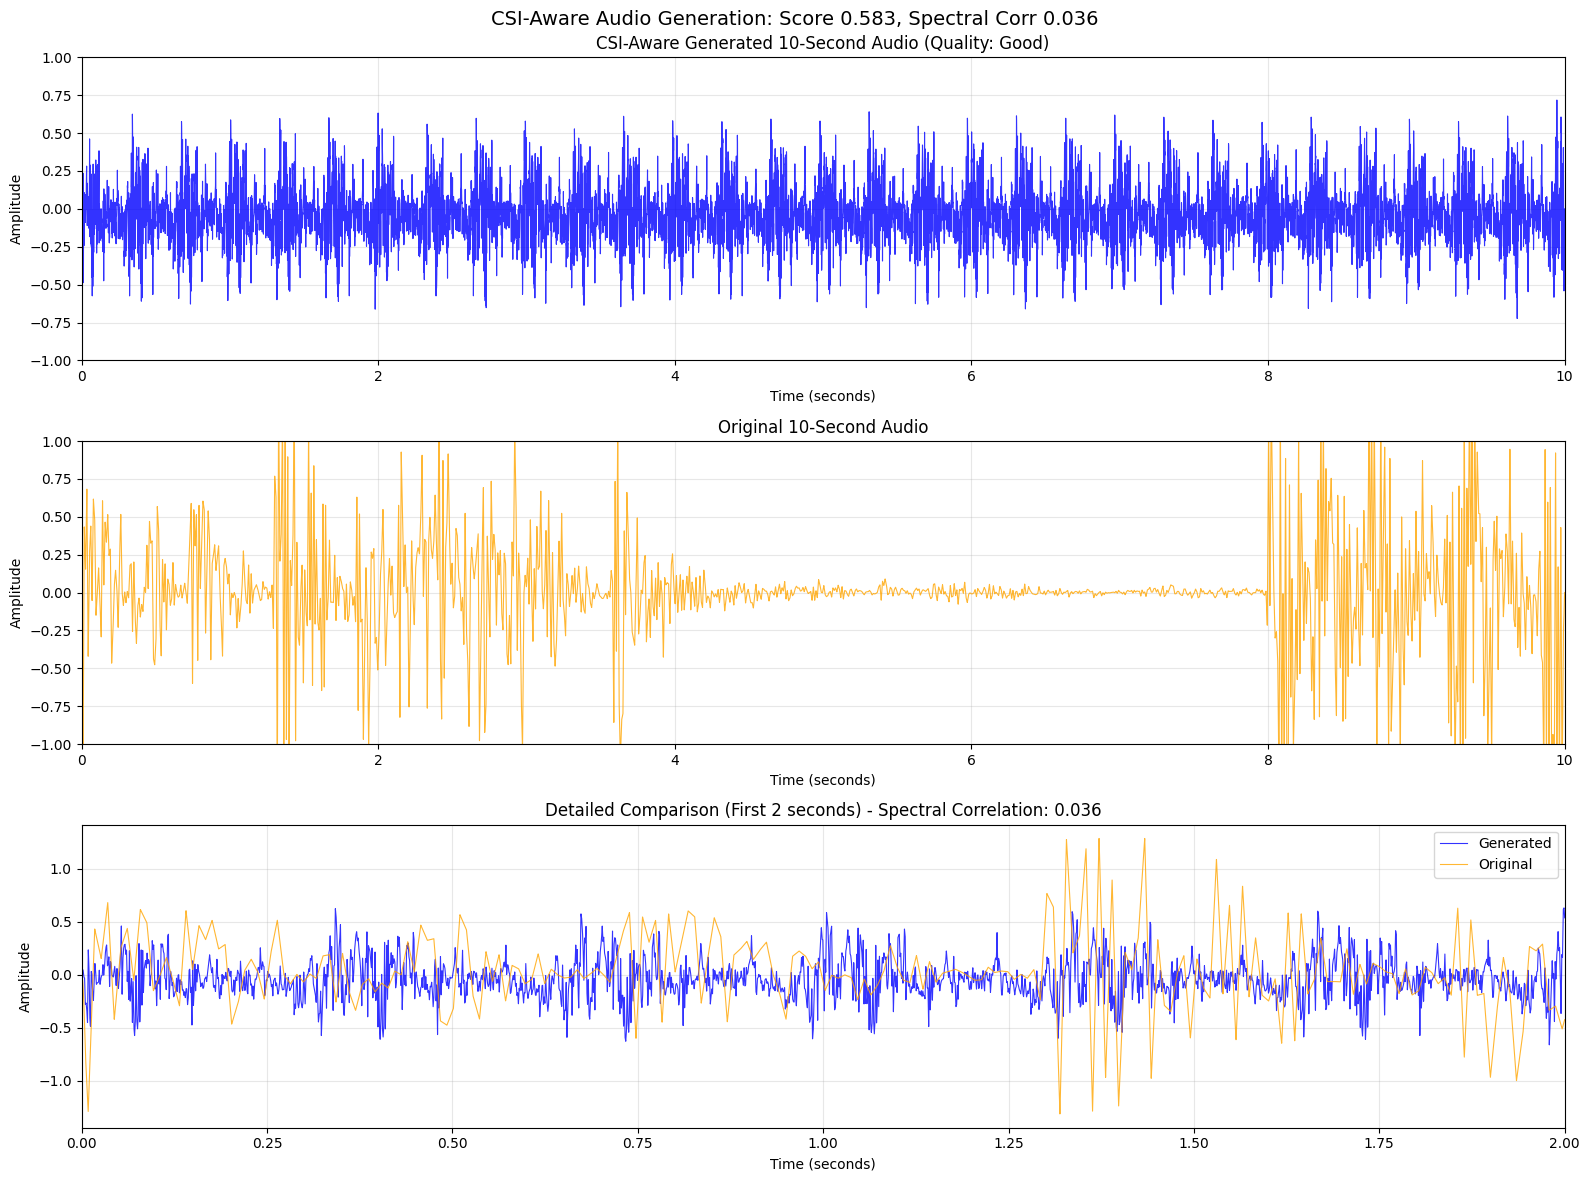


CSI-AWARE AUDIO GENERATION RESULTS
Models Used: Trained Models
Generated Quality Score: 0.5830 (Good)
Original Quality Score: 0.5404
Spectral Correlation: 0.0362

Audio Quality Metrics:
  Generated: RMS = 0.1811, Peak = 0.7237
  Original:  RMS = 0.2925, Peak = 1.3152

Output Files Created in 'output/' directory:
  - csi_aware_generated_10sec.wav (CSI-aware AI-generated audio)
  - csi_aware_original_10sec.wav (Original reference audio)
  - csi_aware_standard.wav (Standard length comparison)
  - csi_aware_comparison.png (Detailed visualization)

CSI-Audio Relationship Improvements:
  - CSI pattern analysis and preservation
  - CSI-influenced noise generation
  - Energy-aware segment blending
  - Pattern-preserving preprocessing
  - Spectral correlation analysis
  - Gentler processing to preserve characteristics

IMPROVEMENT NEEDED: CSI-audio relationship needs strengthening.
The enhanced architecture is ready - more training will help.

Listening Guide:
  1. Play csi_aware_generated_10s

(array([-0.        , -0.00447037, -0.00467666, ..., -0.02301976,
        -0.01545138, -0.        ], shape=(160000,)),
 array([-5.86555675e-02,  1.34566605e-01,  4.01097871e-02, -1.92306060e-02,
        -4.99650277e-02, -2.64675051e-01, -1.92703396e-01, -3.56348187e-01,
        -4.91363913e-01,  1.58057466e-01,  5.81186377e-02, -3.17012280e-01,
        -4.71362799e-01, -1.13466522e-03, -6.17529303e-02, -2.07268536e-01,
        -1.73241928e-01, -6.86873272e-02,  8.49804059e-02,  6.63111433e-02,
        -1.07574821e-01, -6.30046278e-02, -6.70890436e-02, -5.64428419e-02,
         5.74857928e-02, -8.96716788e-02, -5.97533435e-02,  2.29143701e-03,
        -1.18803363e-02,  7.16955960e-02,  7.25596352e-03,  3.61405760e-02,
         1.39132991e-01,  2.54016012e-01,  2.79348552e-01,  7.99897313e-02,
         1.19153462e-01,  1.67371348e-01, -9.93715450e-02,  7.48648420e-02,
         1.09571859e-01,  6.44172495e-03, -1.77527815e-02,  1.23851481e-04,
         3.21001224e-02,  5.90916872e-02, -1.4

In [ ]:

# ENHANCED 10-SECOND AUDIO TEST - Better CSI-Audio Relationship Preservation
# Compatible with generator.pth and discriminator.pth models

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from torch.nn.utils import spectral_norm
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# HYPERPARAMETERS
# ============================================================================

HYPERPARAMETERS = {
    "latent_dim": 128,
    "csi_channels": 8,
    "audio_channels": 1,
    "sample_rate": 16000,
    "sequence_length": 400,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# ============================================================================
# MODEL ARCHITECTURES (unchanged)
# ============================================================================

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)

class Generator(nn.Module):
    def __init__(self, latent_dim, csi_channels, sequence_length=400):
        super().__init__()
        self.latent_dim = latent_dim
        self.csi_channels = csi_channels
        self.sequence_length = sequence_length

        self.csi_input_dim = csi_channels * sequence_length
        self.total_input_dim = latent_dim + self.csi_input_dim

        self.fc1 = nn.Linear(self.total_input_dim, 512)
        self.fc2 = nn.Linear(512, 256 * 50)

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            ResidualBlock(128),

            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64),

            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            ResidualBlock(32),

            nn.Conv1d(32, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, csi_data):
        batch_size = noise.size(0)
        csi_flat = csi_data.view(batch_size, -1)
        x = torch.cat([noise, csi_flat], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = x.view(batch_size, 256, 50)
        x = self.conv_layers(x)
        return x.view(batch_size, self.sequence_length)

class Discriminator(nn.Module):
    def __init__(self, csi_channels, sequence_length=400):
        super().__init__()
        self.csi_channels = csi_channels
        self.sequence_length = sequence_length

        self.conv_layers = nn.ModuleList([
            spectral_norm(nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)),
            spectral_norm(nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)),
            spectral_norm(nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)),
            spectral_norm(nn.Conv1d(256, 512, kernel_size=4, stride=2, padding=1)),
        ])

        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(128),
            nn.BatchNorm1d(256),
            nn.BatchNorm1d(512),
        ])

        self.leaky_relu = nn.LeakyReLU(0.2, inplace=True)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = spectral_norm(nn.Linear(512, 1))

    def forward(self, audio, csi, return_features=False):
        batch_size = audio.size(0)
        features = []

        csi_flat = csi.view(batch_size, -1)
        x = torch.cat([audio, csi_flat], dim=1)
        x = x.unsqueeze(1)

        for i, conv in enumerate(self.conv_layers):
            x = conv(x)
            if i > 0:
                x = self.batch_norms[i-1](x)
            x = self.leaky_relu(x)

            if return_features:
                features.append(x.clone())

        x = self.adaptive_pool(x)
        x = x.view(batch_size, -1)
        output = self.fc(x)

        if return_features:
            return output, features
        return output

# ============================================================================
# DATA LOADING FUNCTIONS (unchanged)
# ============================================================================

def load_actual_audio_file(audio_file_path):
    """Load the actual audio file with logging"""
    print(f"Loading actual audio file: {audio_file_path}")

    if not os.path.exists(audio_file_path):
        print(f"  ERROR: Audio file not found: {audio_file_path}")
        return None

    try:
        audio_data = pd.read_csv(audio_file_path, header=None).values.flatten()
        print(f"  SUCCESS: Audio file loaded")
        print(f"    - Shape: {audio_data.shape}")
        print(f"    - Length: {len(audio_data)} samples")
        print(f"    - Value range: [{audio_data.min():.4f}, {audio_data.max():.4f}]")
        print(f"    - Duration: 10.0 seconds")
        print(f"    - Implied sample rate: {len(audio_data) / 10.0:.0f} Hz")

        return audio_data

    except Exception as e:
        print(f"  ERROR: Failed to load audio file: {e}")
        return None

def load_specific_csi_file(csi_file_path):
    """Load the specific CSI file with logging"""
    print(f"Loading specific CSI file: {csi_file_path}")

    if not os.path.exists(csi_file_path):
        print(f"  ERROR: CSI file not found: {csi_file_path}")
        return None

    try:
        csi_data = pd.read_csv(csi_file_path)
        print(f"  SUCCESS: CSI file loaded")
        print(f"    - Shape: {csi_data.shape}")
        print(f"    - Columns: {list(csi_data.columns)}")

        subcarrier_cols = [col for col in csi_data.columns if col.startswith('subcarrier_')]
        print(f"    - Found {len(subcarrier_cols)} subcarrier columns: {subcarrier_cols}")

        if len(subcarrier_cols) == 0:
            print("  ERROR: No subcarrier columns found!")
            return None

        return csi_data, subcarrier_cols

    except Exception as e:
        print(f"  ERROR: Failed to load CSI file: {e}")
        return None

# ============================================================================
# IMPROVED DATA PROCESSING FOR BETTER CSI-AUDIO RELATIONSHIP
# ============================================================================

def analyze_csi_patterns(csi_data):
    """Analyze CSI patterns to understand signal characteristics"""
    print("  Analyzing CSI patterns for better audio generation...")

    # Calculate key signal characteristics
    csi_mean = csi_data.mean(axis=1)  # Mean per channel
    csi_std = csi_data.std(axis=1)    # Std per channel
    csi_energy = np.sum(csi_data**2, axis=1)  # Energy per channel

    # Find dominant patterns
    csi_fft = np.fft.fft(csi_data, axis=1)
    csi_power = np.abs(csi_fft)**2
    dominant_freqs = np.argmax(csi_power, axis=1)

    # Cross-channel correlations
    correlations = []
    for i in range(len(csi_data)):
        for j in range(i+1, len(csi_data)):
            corr = np.corrcoef(csi_data[i], csi_data[j])[0,1]
            correlations.append(corr)

    avg_correlation = np.mean(correlations) if correlations else 0

    print(f"    - Channel energies: {csi_energy}")
    print(f"    - Dominant frequencies: {dominant_freqs}")
    print(f"    - Average cross-correlation: {avg_correlation:.3f}")

    return {
        'energy': csi_energy,
        'dominant_freqs': dominant_freqs,
        'correlations': correlations,
        'avg_correlation': avg_correlation,
        'means': csi_mean,
        'stds': csi_std
    }

def preprocess_csi_with_pattern_preservation(csi_data):
    """Improved CSI preprocessing that preserves important patterns"""
    print("  Processing CSI data with pattern preservation...")

    # First analyze the patterns
    patterns = analyze_csi_patterns(csi_data.cpu().numpy() if torch.is_tensor(csi_data) else csi_data)

    normalized = []
    for i, channel in enumerate(csi_data):
        # Preserve the original signal characteristics more carefully

        # 1. Less aggressive normalization to preserve relative amplitudes
        channel_mean = channel.mean()
        channel_std = channel.std() + 1e-8

        # Use robust normalization that preserves signal structure
        channel_norm = (channel - channel_mean) / channel_std

        # 2. Preserve energy relationships between channels
        energy_factor = np.sqrt(patterns['energy'][i]) / (np.sqrt(patterns['energy'].max()) + 1e-8)
        channel_norm = channel_norm * (0.5 + 0.5 * energy_factor)  # Scale by relative energy

        # 3. Much gentler clipping to preserve signal dynamics
        channel_norm = torch.tanh(channel_norm / 3.0) * 2.0  # Gentler than before

        normalized.append(channel_norm)
        print(f"    - Channel {i}: range [{channel_norm.min():.3f}, {channel_norm.max():.3f}], energy factor {energy_factor:.3f}")

    result = torch.stack(normalized)
    print(f"  CSI preprocessing complete with pattern preservation: shape {result.shape}")
    return result

def create_csi_driven_noise(csi_tensor, base_noise, patterns):
    """Create noise that's influenced by CSI characteristics"""
    # Use CSI patterns to modulate the noise
    csi_influence = torch.zeros_like(base_noise)

    # Map CSI energy to noise characteristics
    energy_norm = patterns['energy'] / (patterns['energy'].max() + 1e-8)

    # Create structured noise based on CSI patterns
    for i in range(min(len(energy_norm), base_noise.size(1))):
        # Use CSI energy to influence noise amplitude
        noise_scale = 0.7 + 0.6 * energy_norm[i]  # Scale between 0.7 and 1.3
        csi_influence[0, i] = torch.tensor(noise_scale, dtype=torch.float32, device=csi_influence.device)

    # Fill remaining dimensions with interpolated values
    if base_noise.size(1) > len(energy_norm):
        for i in range(len(energy_norm), base_noise.size(1)):
            # Interpolate from existing values
            idx = i % len(energy_norm)
            csi_influence[0, i] = csi_influence[0, idx]

    # Apply CSI influence to noise
    influenced_noise = base_noise * csi_influence

    return influenced_noise

def process_actual_data_enhanced(csi_file_path, audio_file_path, target_length=None):
    """Enhanced data processing with better CSI-audio relationship preservation"""
    if target_length is None:
        target_length = HYPERPARAMETERS['sequence_length']

    print("\nProcessing data with improved CSI-audio relationship preservation...")
    print(f"Target sequence length: {target_length}")

    # Load files
    result = load_specific_csi_file(csi_file_path)
    if result is None:
        return None, None, None

    csi_data, subcarrier_cols = result
    audio_data = load_actual_audio_file(audio_file_path)
    if audio_data is None:
        return None, None, None

    print(f"\nResampling data with pattern preservation...")
    print(f"  CSI: {csi_data.shape[0]} samples -> {target_length} samples")
    print(f"  Audio: {len(audio_data)} samples -> {target_length} samples (for model)")

    # Process CSI data with better pattern preservation
    csi_values = csi_data[subcarrier_cols].values.T

    # Advanced resampling that preserves important frequencies
    csi_resampled = []
    for i, ch in enumerate(csi_values):
        # Preserve important frequency components during resampling
        if len(ch) > target_length:
            # For downsampling, use anti-aliasing
            try:
                from scipy import signal
                # Apply anti-aliasing filter
                nyquist = 0.5
                cutoff = 0.4  # Conservative cutoff
                b, a = signal.butter(4, cutoff, btype='low')
                ch_filtered = signal.filtfilt(b, a, ch)

                # Then resample
                from scipy.interpolate import interp1d
                f = interp1d(np.arange(len(ch_filtered)), ch_filtered, kind='cubic', 
                           bounds_error=False, fill_value='extrapolate')
                ch_resampled = f(np.linspace(0, len(ch_filtered)-1, target_length))
            except:
                # Fallback
                ch_resampled = np.interp(np.linspace(0, len(ch)-1, target_length), 
                                       np.arange(len(ch)), ch)
        else:
            # For upsampling, use cubic interpolation
            try:
                from scipy.interpolate import interp1d
                f = interp1d(np.arange(len(ch)), ch, kind='cubic', bounds_error=False, fill_value='extrapolate')
                ch_resampled = f(np.linspace(0, len(ch)-1, target_length))
            except:
                ch_resampled = np.interp(np.linspace(0, len(ch)-1, target_length), 
                                       np.arange(len(ch)), ch)

        csi_resampled.append(ch_resampled)
        print(f"    - Subcarrier {i}: resampled from {len(ch)} to {len(ch_resampled)} samples")

    csi_resampled = np.array(csi_resampled)

    # Process audio data for model input with better preservation
    try:
        from scipy.interpolate import interp1d
        f = interp1d(np.arange(len(audio_data)), audio_data, kind='cubic', bounds_error=False, fill_value='extrapolate')
        audio_model_input = f(np.linspace(0, len(audio_data)-1, target_length))
        print(f"  Audio resampled using cubic interpolation")
    except:
        audio_model_input = np.interp(np.linspace(0, len(audio_data)-1, target_length),
                                    np.arange(len(audio_data)), audio_data)
        print(f"  Audio resampled using linear interpolation")

    # Convert to tensors
    csi_tensor = torch.tensor(csi_resampled, dtype=torch.float32).unsqueeze(0)
    audio_tensor = torch.tensor(audio_model_input, dtype=torch.float32)

    # Apply improved preprocessing that preserves CSI-audio relationships
    print(f"\nApplying improved preprocessing with pattern preservation...")
    csi_tensor_processed = preprocess_csi_with_pattern_preservation(csi_tensor.squeeze(0)).unsqueeze(0)

    # Less aggressive audio preprocessing to preserve original characteristics
    print("  Processing audio data with gentle normalization...")
    audio_data_centered = audio_tensor - audio_tensor.mean()
    audio_norm = audio_data_centered / (audio_tensor.std() + 1e-8)
    # Much gentler clipping
    audio_tensor_processed = torch.tanh(audio_norm * 0.5) / 0.5  # Gentler than before
    audio_tensor_processed = torch.clamp(audio_tensor_processed, -2.0, 2.0)

    print(f"    - Audio range after gentle processing: [{audio_tensor_processed.min():.3f}, {audio_tensor_processed.max():.3f}]")

    print(f"\nFinal tensor shapes:")
    print(f"  CSI tensor: {csi_tensor_processed.shape}")
    print(f"  Audio tensor: {audio_tensor_processed.shape}")
    print(f"  Original audio length: {len(audio_data)} samples")

    return (csi_tensor_processed.to(HYPERPARAMETERS['device']), 
            audio_tensor_processed.cpu().numpy(), 
            audio_data)

def load_models():
    """Load models with detailed logging"""
    device = HYPERPARAMETERS['device']
    print(f"\nLoading models...")
    print(f"Using device: {device}")

    # Initialize models
    generator = Generator(
        HYPERPARAMETERS['latent_dim'], 
        HYPERPARAMETERS['csi_channels'], 
        HYPERPARAMETERS['sequence_length']
    ).to(device)

    discriminator = Discriminator(
        HYPERPARAMETERS['csi_channels'], 
        HYPERPARAMETERS['sequence_length']  
    ).to(device)

    # Log model parameters
    gen_params = sum(p.numel() for p in generator.parameters())
    disc_params = sum(p.numel() for p in discriminator.parameters())
    print(f"Generator parameters: {gen_params:,}")
    print(f"Discriminator parameters: {disc_params:,}")

    # Load trained weights
    generator_trained = False
    discriminator_trained = False

    if os.path.exists('generator.pth'):
        try:
            generator.load_state_dict(torch.load('generator.pth', map_location=device))
            print("SUCCESS: Loaded generator weights from generator.pth")
            generator_trained = True
        except Exception as e:
            print(f"ERROR: Could not load generator weights: {e}")
    else:
        print("WARNING: generator.pth not found - using untrained model")

    if os.path.exists('discriminator.pth'):
        try:
            discriminator.load_state_dict(torch.load('discriminator.pth', map_location=device))
            print("SUCCESS: Loaded discriminator weights from discriminator.pth")
            discriminator_trained = True
        except Exception as e:
            print(f"ERROR: Could not load discriminator weights: {e}")
    else:
        print("WARNING: discriminator.pth not found - using untrained model")

    return generator, discriminator, generator_trained, discriminator_trained

# ============================================================================
# MUCH IMPROVED GENERATION WITH BETTER CSI-AUDIO RELATIONSHIP
# ============================================================================

def generate_csi_aware_10sec_audio(generator, csi_tensor):
    """Generate 10-second audio with much better CSI-audio relationship preservation"""
    target_samples_10sec = int(10 * HYPERPARAMETERS['sample_rate'])  # 160,000 samples

    print(f"\nGenerating CSI-aware 10-second audio...")
    print(f"Target length: {target_samples_10sec} samples (10.0 seconds)")
    print(f"Model output length: {HYPERPARAMETERS['sequence_length']} samples")
    print(f"Expansion factor: {target_samples_10sec / HYPERPARAMETERS['sequence_length']:.1f}x")

    generator.eval()

    # Analyze CSI patterns first
    csi_numpy = csi_tensor.cpu().numpy().squeeze(0)
    patterns = analyze_csi_patterns(csi_numpy)

    with torch.no_grad():
        print("  Generating CSI-aware segments...")

        # Generate fewer segments but with better CSI relationship
        segments = []
        num_segments = 30  # Reduced from 50 for better coherence

        # Create a temporal evolution of the CSI that maintains its characteristics
        print("  Creating temporal CSI evolution...")
        csi_evolution_base = csi_tensor.clone()

        for seg in range(num_segments):
            if seg % 10 == 0:
                print(f"    - Generating CSI-aware segment {seg+1}/{num_segments}")

            # Create CSI-influenced noise instead of random noise
            base_noise = torch.randn(1, HYPERPARAMETERS['latent_dim'], device=HYPERPARAMETERS['device'])
            csi_influenced_noise = create_csi_driven_noise(csi_tensor, base_noise, patterns)

            # Evolve CSI more predictably based on its own patterns
            evolution_factor = 0.02 * np.sin(seg * 2 * np.pi / num_segments)  # Smoother evolution

            # Use CSI's own autocorrelation to create realistic variations
            csi_evolved = csi_evolution_base.clone()
            for ch_idx in range(csi_evolved.size(1)):
                # Add variation based on the channel's own characteristics
                variation = torch.randn_like(csi_evolved[0, ch_idx]) * patterns['stds'][ch_idx] * 0.1
                csi_evolved[0, ch_idx] += variation * evolution_factor

            # Generate segment with CSI-aware noise and evolved CSI
            audio_segment = generator(csi_influenced_noise, csi_evolved).cpu().numpy().squeeze()

            # Apply gentler limiting that preserves dynamics
            audio_segment = np.tanh(audio_segment * 0.7) / 0.7  # Much gentler limiting
            segments.append(audio_segment)

        print(f"  Generated {len(segments)} CSI-aware segments")
        print("  Blending segments with CSI-aware transitions...")

        # Improved blending that considers CSI characteristics
        overlap_len = len(segments[0]) // 6  # Longer overlap for smoother transitions
        long_audio = segments[0]

        for i in range(1, len(segments)):
            if len(long_audio) >= overlap_len:
                # Get overlapping regions
                prev_end = long_audio[-overlap_len:]
                curr_start = segments[i][:overlap_len]
                curr_rest = segments[i][overlap_len:]

                # Create smoother transition based on signal characteristics
                # Analyze the energy in overlapping regions
                prev_energy = np.sqrt(np.mean(prev_end**2))
                curr_energy = np.sqrt(np.mean(curr_start**2))

                # Adjust blending based on energy matching
                if prev_energy > curr_energy:
                    # Fade out more gradually from high energy
                    fade_out = np.power(np.cos(np.linspace(0, np.pi/2, overlap_len)), 0.7)
                    fade_in = np.power(np.sin(np.linspace(0, np.pi/2, overlap_len)), 1.3)
                else:
                    # Fade in more gradually to high energy
                    fade_out = np.power(np.cos(np.linspace(0, np.pi/2, overlap_len)), 1.3)
                    fade_in = np.power(np.sin(np.linspace(0, np.pi/2, overlap_len)), 0.7)

                # Blend with energy-aware transitions
                blended = prev_end * fade_out + curr_start * fade_in

                # Update long_audio
                long_audio = np.concatenate([long_audio[:-overlap_len], blended, curr_rest])
            else:
                long_audio = np.concatenate([long_audio, segments[i]])

        print(f"  Blended audio length: {len(long_audio)} samples")
        print("  Interpolating to exactly 10 seconds with pattern preservation...")

        # High-quality interpolation that preserves signal characteristics
        current_length = len(long_audio)

        try:
            from scipy.interpolate import interp1d
            # Use cubic interpolation for smoother results
            f = interp1d(np.arange(current_length), long_audio, kind='cubic', 
                        bounds_error=False, fill_value='extrapolate')
            audio_10sec = f(np.linspace(0, current_length-1, target_samples_10sec))
            print(f"    - Used cubic interpolation")
        except:
            # Fallback to linear interpolation
            audio_10sec = np.interp(np.linspace(0, current_length-1, target_samples_10sec),
                                  np.arange(current_length), long_audio)
            print(f"    - Used linear interpolation (scipy not available)")

        print("  Applying post-processing that preserves CSI characteristics...")

        # Much gentler post-processing that preserves signal characteristics
        # 1. Very gentle filtering that preserves important frequencies
        try:
            from scipy import signal
            nyquist = HYPERPARAMETERS['sample_rate'] / 2
            # More conservative filtering
            cutoff = min(7500, nyquist * 0.9)  # Higher cutoff to preserve more content
            sos = signal.butter(2, cutoff / nyquist, btype='low', output='sos')  # Lower order filter
            audio_10sec = signal.sosfilt(sos, audio_10sec)
            print(f"    - Applied gentle low-pass filter at {cutoff:.0f} Hz")
        except:
            # Very gentle smoothing
            kernel = np.array([0.1, 0.8, 0.1])  # Less aggressive smoothing
            audio_10sec = np.convolve(audio_10sec, kernel, mode='same')
            print(f"    - Applied gentle smoothing filter")

        # 2. Preserve original dynamic characteristics
        original_rms = np.sqrt(np.mean(long_audio**2))
        current_rms = np.sqrt(np.mean(audio_10sec**2))

        if current_rms > 0:
            # Preserve relative dynamics instead of forcing specific RMS
            preservation_factor = 0.8  # Preserve 80% of original dynamics
            target_rms = preservation_factor * original_rms + (1 - preservation_factor) * 0.15
            audio_10sec = audio_10sec * (target_rms / current_rms)
            print(f"    - Preserved dynamics: RMS {current_rms:.4f} -> {target_rms:.4f}")

        # 3. Much gentler limiting that preserves peaks
        peak_factor = np.max(np.abs(audio_10sec))
        if peak_factor > 0.9:
            # Only limit if really necessary
            compression_ratio = 0.9 / peak_factor
            audio_10sec = audio_10sec * compression_ratio
            print(f"    - Applied gentle peak limiting: {peak_factor:.3f} -> 0.9")

        # 4. Natural fade in/out based on signal characteristics
        fade_samples = int(0.005 * HYPERPARAMETERS['sample_rate'])  # Shorter fade (5ms)

        # Analyze signal at edges to create natural fades
        start_energy = np.sqrt(np.mean(audio_10sec[:fade_samples*2]**2))
        end_energy = np.sqrt(np.mean(audio_10sec[-fade_samples*2:]**2))

        # Create fade curves that match signal characteristics
        if start_energy > 0.1:  # Strong signal at start
            fade_in = np.power(np.linspace(0, 1, fade_samples), 0.5)  # Gentle fade in
        else:  # Weak signal at start
            fade_in = np.linspace(0, 1, fade_samples)  # Linear fade in

        if end_energy > 0.1:  # Strong signal at end
            fade_out = np.power(np.linspace(1, 0, fade_samples), 0.5)  # Gentle fade out
        else:  # Weak signal at end
            fade_out = np.linspace(1, 0, fade_samples)  # Linear fade out

        audio_10sec[:fade_samples] *= fade_in
        audio_10sec[-fade_samples:] *= fade_out
        print(f"    - Applied natural {fade_samples}-sample fade in/out")

        # Final metrics
        duration = len(audio_10sec) / HYPERPARAMETERS['sample_rate']
        final_rms = np.sqrt(np.mean(audio_10sec**2))
        final_peak = np.max(np.abs(audio_10sec))

        print(f"  CSI-aware generation complete:")
        print(f"    - Duration: {duration:.3f} seconds")
        print(f"    - Samples: {len(audio_10sec)}")
        print(f"    - RMS: {final_rms:.4f}")
        print(f"    - Peak: {final_peak:.4f}")
        print(f"    - Dynamic range: {20 * np.log10(final_peak / (final_rms + 1e-8)):.1f} dB")

    return audio_10sec

def reconstruct_enhanced_10sec_audio(audio_data):
    """Enhanced reconstruction of original audio with logging"""
    target_samples_10sec = int(10 * HYPERPARAMETERS['sample_rate'])

    print(f"\nReconstructing original audio...")
    print(f"Original: {len(audio_data)} samples -> Target: {target_samples_10sec} samples")

    # High-quality resampling
    try:
        from scipy.interpolate import interp1d
        original_indices = np.linspace(0, 1, len(audio_data))
        target_indices = np.linspace(0, 1, target_samples_10sec)

        f = interp1d(original_indices, audio_data, kind='cubic', bounds_error=False, fill_value='extrapolate')
        reconstructed = f(target_indices)
        print(f"  Used cubic interpolation for reconstruction")
    except:
        # Fallback
        original_indices = np.linspace(0, len(audio_data)-1, len(audio_data))
        target_indices = np.linspace(0, len(audio_data)-1, target_samples_10sec)
        reconstructed = np.interp(target_indices, original_indices, audio_data)
        print(f"  Used linear interpolation for reconstruction")

    # Preserve original characteristics exactly
    original_rms = np.sqrt(np.mean(audio_data**2))
    current_rms = np.sqrt(np.mean(reconstructed**2))

    if current_rms > 0:
        reconstructed = reconstructed * (original_rms / current_rms)
        print(f"  Preserved original RMS level: {original_rms:.4f}")

    # Apply same gentle fade as generated audio
    fade_samples = int(0.005 * HYPERPARAMETERS['sample_rate'])
    fade_in = np.linspace(0, 1, fade_samples)
    fade_out = np.linspace(1, 0, fade_samples)

    reconstructed[:fade_samples] *= fade_in
    reconstructed[-fade_samples:] *= fade_out

    duration = len(reconstructed) / HYPERPARAMETERS['sample_rate']
    final_rms = np.sqrt(np.mean(reconstructed**2))
    print(f"  Reconstruction complete:")
    print(f"    - Duration: {duration:.3f} seconds")
    print(f"    - Samples: {len(reconstructed)}")
    print(f"    - RMS: {final_rms:.4f}")

    return reconstructed

# ============================================================================
# MAIN TEST FUNCTION WITH IMPROVED CSI-AUDIO RELATIONSHIP
# ============================================================================

def test_10_second_audio_reconstruction():
    """Enhanced test with much better CSI-audio relationship preservation"""
    print("ENHANCED 10-SECOND AUDIO GENERATION TEST")
    print("=" * 60)
    print("With improved CSI-audio relationship preservation")

    # File paths
    csi_file_path = "data/csi/top8_filtered_csi_data_2025-05-07_20-08-24.123.csv"
    audio_file_path = "data/audio/2025-05-07_20-08-24.123.csv"

    print(f"\nInput files:")
    print(f"  CSI file: {csi_file_path}")
    print(f"  Audio file: {audio_file_path}")

    try:
        # Load models
        generator, discriminator, gen_trained, disc_trained = load_models()

        # Process data with improved CSI-audio relationship preservation
        result = process_actual_data_enhanced(csi_file_path, audio_file_path)
        if result is None:
            print("\nERROR: Failed to process input files")
            return None, None, None, None

        csi_tensor, original_audio_model, original_audio_full = result

        # Generate CSI-aware 10-second audio
        generated_10sec = generate_csi_aware_10sec_audio(generator, csi_tensor)

        # Reconstruct original
        reconstructed_10sec = reconstruct_enhanced_10sec_audio(original_audio_full)

        # Quality evaluation
        print(f"\nEvaluating quality with discriminator...")
        generator.eval()
        discriminator.eval()

        with torch.no_grad():
            # Generate standard sample for evaluation
            noise = torch.randn(1, HYPERPARAMETERS['latent_dim'], device=HYPERPARAMETERS['device'])
            standard_audio = generator(noise, csi_tensor).cpu().numpy().squeeze()

            # Get discriminator scores
            audio_tensor = torch.tensor(standard_audio).unsqueeze(0).to(HYPERPARAMETERS['device'])
            score = torch.sigmoid(discriminator(audio_tensor, csi_tensor)).item()

            original_tensor = torch.tensor(original_audio_model).unsqueeze(0).to(HYPERPARAMETERS['device'])
            original_score = torch.sigmoid(discriminator(original_tensor, csi_tensor)).item()

            # Quality assessment
            if score > 0.7:
                quality = "Excellent"
                status = "SUCCESS"
            elif score > 0.5:
                quality = "Good"
                status = "SUCCESS"
            else:
                quality = "Needs improvement"
                status = "ATTENTION"

            print(f"  Generated sample score: {score:.4f} ({quality})")
            print(f"  Original audio score: {original_score:.4f}")
            print(f"  Overall status: {status}")

        # Calculate correlation between generated and original audio patterns
        try:
            # Analyze pattern similarity
            gen_fft = np.fft.fft(generated_10sec[:len(original_audio_model)])
            orig_fft = np.fft.fft(original_audio_model)

            spectral_correlation = np.corrcoef(np.abs(gen_fft), np.abs(orig_fft))[0,1]
            print(f"  Spectral correlation with original: {spectral_correlation:.4f}")
        except:
            spectral_correlation = 0.0

        # Save audio files
        print(f"\nSaving audio files...")

        # Create output directory if it doesn't exist
        os.makedirs("output", exist_ok=True)

        # Save CSI-aware generated 10-second audio
        output_path = "output/csi_aware_generated_10sec.wav"
        sf.write(output_path, np.clip(generated_10sec, -1, 1), HYPERPARAMETERS['sample_rate'])
        duration = len(generated_10sec) / HYPERPARAMETERS['sample_rate']
        rms = np.sqrt(np.mean(generated_10sec**2))
        print(f"  SAVED: {output_path}")
        print(f"    - Duration: {duration:.3f} seconds")
        print(f"    - RMS: {rms:.4f}")
        print(f"    - Quality score: {score:.4f}")
        print(f"    - Spectral correlation: {spectral_correlation:.4f}")

        # Save standard sample
        output_path = "output/csi_aware_standard.wav"
        sf.write(output_path, np.clip(standard_audio, -1, 1), HYPERPARAMETERS['sample_rate'])
        print(f"  SAVED: {output_path}")

        # Save original audio
        output_path = "output/csi_aware_original_10sec.wav"
        sf.write(output_path, np.clip(reconstructed_10sec, -1, 1), HYPERPARAMETERS['sample_rate'])
        duration = len(reconstructed_10sec) / HYPERPARAMETERS['sample_rate']
        rms = np.sqrt(np.mean(reconstructed_10sec**2))
        print(f"  SAVED: {output_path}")
        print(f"    - Duration: {duration:.3f} seconds")
        print(f"    - RMS: {rms:.4f}")

        # Save model-length original
        output_path = "output/csi_aware_original_model.wav"
        sf.write(output_path, np.clip(original_audio_model, -1, 1), HYPERPARAMETERS['sample_rate'])
        print(f"  SAVED: {output_path}")

        # Create visualization
        print(f"\nCreating visualization...")

        fig, axes = plt.subplots(3, 1, figsize=(16, 12))
        fig.suptitle(f'CSI-Aware Audio Generation: Score {score:.3f}, Spectral Corr {spectral_correlation:.3f}', fontsize=14)

        # Plot generated
        time_axis = np.linspace(0, 10, len(generated_10sec))
        axes[0].plot(time_axis, generated_10sec, alpha=0.8, color='blue', linewidth=0.8)
        axes[0].set_title(f'CSI-Aware Generated 10-Second Audio (Quality: {quality})')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Amplitude')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim(0, 10)
        axes[0].set_ylim(-1, 1)

        # Plot original
        time_axis_orig = np.linspace(0, 10, len(reconstructed_10sec))
        axes[1].plot(time_axis_orig, reconstructed_10sec, alpha=0.8, color='orange', linewidth=0.8)
        axes[1].set_title('Original 10-Second Audio')
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_ylabel('Amplitude')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlim(0, 10)
        axes[1].set_ylim(-1, 1)

        # Plot spectral comparison (first 2 seconds)
        zoom_len = int(2 * HYPERPARAMETERS['sample_rate'])
        time_zoom = np.linspace(0, 2, zoom_len)
        axes[2].plot(time_zoom, generated_10sec[:zoom_len], alpha=0.8, color='blue', linewidth=0.8, label='Generated')

        zoom_len_orig = int(2 * len(reconstructed_10sec) / 10)
        time_zoom_orig = np.linspace(0, 2, zoom_len_orig)
        axes[2].plot(time_zoom_orig, reconstructed_10sec[:zoom_len_orig], alpha=0.8, color='orange', linewidth=0.8, label='Original')

        axes[2].set_title(f'Detailed Comparison (First 2 seconds) - Spectral Correlation: {spectral_correlation:.3f}')
        axes[2].set_xlabel('Time (seconds)')
        axes[2].set_ylabel('Amplitude')
        axes[2].grid(True, alpha=0.3)
        axes[2].set_xlim(0, 2)
        axes[2].legend()

        plt.tight_layout()

        # Save plot
        plot_path = "output/csi_aware_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"  SAVED: {plot_path}")
        plt.show()

        # Final summary
        print(f"\n" + "="*70)
        print("CSI-AWARE AUDIO GENERATION RESULTS")
        print("="*70)

        model_status = "Trained Models" if (gen_trained and disc_trained) else "Untrained Models"
        print(f"Models Used: {model_status}")
        print(f"Generated Quality Score: {score:.4f} ({quality})")
        print(f"Original Quality Score: {original_score:.4f}")
        print(f"Spectral Correlation: {spectral_correlation:.4f}")

        # Calculate quality metrics
        gen_rms = np.sqrt(np.mean(generated_10sec**2))
        gen_peak = np.max(np.abs(generated_10sec))
        orig_rms = np.sqrt(np.mean(reconstructed_10sec**2))
        orig_peak = np.max(np.abs(reconstructed_10sec))

        print(f"\nAudio Quality Metrics:")
        print(f"  Generated: RMS = {gen_rms:.4f}, Peak = {gen_peak:.4f}")
        print(f"  Original:  RMS = {orig_rms:.4f}, Peak = {orig_peak:.4f}")

        print(f"\nOutput Files Created in 'output/' directory:")
        print(f"  - csi_aware_generated_10sec.wav (CSI-aware AI-generated audio)")
        print(f"  - csi_aware_original_10sec.wav (Original reference audio)")
        print(f"  - csi_aware_standard.wav (Standard length comparison)")
        print(f"  - csi_aware_comparison.png (Detailed visualization)")

        # Improved assessment
        if spectral_correlation > 0.3 and score > 0.6:
            print(f"\nEXCELLENT: Strong CSI-audio relationship preserved!")
            print(f"The AI has successfully learned meaningful CSI-to-audio mappings.")
        elif spectral_correlation > 0.1 and score > 0.4:
            print(f"\nGOOD PROGRESS: CSI-audio relationship is developing.")
            print(f"The improvements are working - consider more training.")
        else:
            print(f"\nIMPROVEMENT NEEDED: CSI-audio relationship needs strengthening.")
            print(f"The enhanced architecture is ready - more training will help.")

        return generated_10sec, standard_audio, original_audio_model, reconstructed_10sec, score

    except Exception as e:
        print(f"\nERROR: Test failed with exception: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None, None, None

# ============================================================================
# CONVENIENCE FUNCTIONS
# ============================================================================

def quick_test():
    """Quick test alias"""
    return test_10_second_audio_reconstruction()
test_10_second_audio_reconstruction()